## **1.1 Import Libraries**

In [1]:
#Importing Libraries
import pandas as pd #for data manipulation and analysis
import numpy as np
import seaborn as sns #for visualization purposes
import matplotlib.pyplot as plt #for visualization purposes

#Libraries pertaining to Linear Regression
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error

#Libraries pertaining to Decision Tree
!pip install pydotplus #interface for graph visualisation
!pip install graphviz #for graph visualisation
from pandas.io.parsers.readers import annotations
from sklearn.tree import DecisionTreeRegressor # Import Decision Tree Regressor
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for model evaluation

#Libraries pertaining to KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
#import scaler
from sklearn.preprocessing import StandardScaler

#Libraries pertaining to ANN - MLPRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#Libraries pertaining to ANN - Keras
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import History

#Libraries pertaining to Ensemble Learning
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import StackingRegressor

#Libraries pertaining to K-Means Clustering
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import mutual_info_score
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib.cm as cm

## **1.2 Loading and Inspecting Data**

1.   Load the dataset
2.   Explore the data

In [ ]:
#Importing and loading dataset
var = pd.read_csv("data/FoodieBay.csv")


In [4]:
#explore the dataset
print(var)

                                                     url  \
0      https://www.zomato.com/bangalore/d2v-cafe-1-ba...   
1      https://www.zomato.com/bangalore/the-burger-pl...   
2      https://www.zomato.com/bangalore/millet-mama-b...   
3      https://www.zomato.com/bangalore/red-onion-sha...   
4      https://www.zomato.com/bangalore/chaiywaala-da...   
...                                                  ...   
40125  https://www.zomato.com/bangalore/yumlane-brook...   
40126  https://www.zomato.com/bangalore/american-dess...   
40127  https://www.zomato.com/bangalore/new-arya-bhav...   
40128  https://www.zomato.com/bangalore/le-charcoal-x...   
40129  https://www.zomato.com/bangalore/kaati-zone-ch...   

                                                 address                 name  \
0      173/218, GF, Opposite Ranka Colony, Bannerghat...             D2V Cafe   
1      2nd Floor, MMR Plaza, Above DCB Bank, Sarjapur...     The Burger Place   
2      Next To Surana College, South

In [5]:
#Inspect the dataset shape, variables and data types.
var.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40130 entries, 0 to 40129
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 40130 non-null  object 
 1   address             40130 non-null  object 
 2   name                40130 non-null  object 
 3   phone               39246 non-null  object 
 4   location            40130 non-null  object 
 5   rest_type           40130 non-null  object 
 6   cuisines            40112 non-null  object 
 7   menu_item           40130 non-null  object 
 8   listed_in_type      40130 non-null  object 
 9   listed_in_city      40130 non-null  object 
 10  online_order        40130 non-null  object 
 11  book_table          40130 non-null  object 
 12  ave_cost_for_two    39890 non-null  float64
 13  dish_liked          17351 non-null  object 
 14  votes               40130 non-null  int64  
 15  ave_review_ranking  33751 non-null  float64
 16  rate

In [6]:
#Prints the number or rows and columns
print('Sample size:', var.shape[0])
print('Number of columns:', var.shape[1])

Sample size: 40130
Number of columns: 17


In [7]:
#Prints the first 5 rows
var.head(5)

,url,address,name,phone,location,rest_type,cuisines,menu_item,listed_in_type,listed_in_city,online_order,book_table,ave_cost_for_two,dish_liked,votes,ave_review_ranking,rate
0,https://www.zomato.com/bangalore/d2v-cafe-1-ba...,"173/218, GF, Opposite Ranka Colony, Bannerghat...",D2V Cafe,+91 9886986111\r\n+91 8550051111,Bannerghatta Road,Cafe,Cafe,[],Cafes,JP Nagar,No,No,700.0,NaN,13,4.75,3.6
1,https://www.zomato.com/bangalore/the-burger-pl...,"2nd Floor, MMR Plaza, Above DCB Bank, Sarjapur...",The Burger Place,+91 9108974600,Koramangala 1st Block,Quick Bites,"Burger, Continental, Fast Food",[],Dine-out,Koramangala 5th Block,Yes,No,400.0,NaN,28,4.50,3.8
2,https://www.zomato.com/bangalore/millet-mama-b...,"Next To Surana College, South End Circle, Basa...",Millet Mama,+91 7411918648\r\n+91 9986975625,Basavanagudi,Quick Bites,"South Indian, Healthy Food",[],Delivery,Jayanagar,Yes,No,200.0,NaN,18,4.00,3.9
3,https://www.zomato.com/bangalore/red-onion-sha...,"Money Chambers Double Road, Shanti Nagar, Bang...",Red Onion,+91 8867253669,Shanti Nagar,Casual Dining,"Chinese, North Indian, Biryani, Kebab","['Hyderabadi Biryani', 'Special Veg Combo', 'S...",Delivery,Brigade Road,Yes,Yes,1200.0,"Fish, Dumplings, Biryani, Paneer Tikka Masala,...",550,4.80,4.3
4,https://www.zomato.com/bangalore/chaiywaala-da...,"Shop 67, 69, 70, Inside Ramaiah Campus, New BE...",Chaiywaala Da Dhaba,+91 8217431260\n+91 7975991975,New BEL Road,Cafe,"Cafe, Tea",[],Dine-out,New BEL Road,Yes,No,250.0,"Ginger Chai, Pakoda, Tea, Paneer Thali, Chole ...",67,3.00,3.7


In [8]:
#Prints the last 5 rows
var.tail(5)

,url,address,name,phone,location,rest_type,cuisines,menu_item,listed_in_type,listed_in_city,online_order,book_table,ave_cost_for_two,dish_liked,votes,ave_review_ranking,rate
40125,https://www.zomato.com/bangalore/yumlane-brook...,"ACES Layout Road, Kundanahalli Gate, Brookefie...",Yumlane,NaN,Brookefield,"Takeaway, Delivery","Pizza, Fast Food",[],Delivery,Whitefield,No,No,NaN,NaN,25,2.000000,2.9
40126,https://www.zomato.com/bangalore/american-dess...,"18, 2nd H Cross, Dodda Banaswadi Main Road, Ne...",American Desserts,+91 9686415784,Banaswadi,"Takeaway, Delivery","Desserts, Bakery",[],Delivery,Kammanahalli,Yes,No,500.0,NaN,23,3.454545,3.6
40127,https://www.zomato.com/bangalore/new-arya-bhav...,"113, MG Road, Bangalore",New Arya Bhavan,080 40913062,MG Road,Quick Bites,"Street Food, Beverages, North Indian",[],Delivery,MG Road,No,No,300.0,NaN,23,3.454545,3.1
40128,https://www.zomato.com/bangalore/le-charcoal-x...,"2334, Aarush Arcade, 17th Cross, 1st Sector, H...",Le Charcoal Xpress,+91 9036300066\r\n+91 9036300088,HSR,Quick Bites,"Arabian, BBQ, Rolls, Chinese",[],Delivery,Bellandur,Yes,No,500.0,"Pita Bread, Rolls, Shawarma Roll, Lebanese Sha...",162,3.500000,4.0
40129,https://www.zomato.com/bangalore/kaati-zone-ch...,"48, Triumph Towers, Church Street, Bangalore",Kaati Zone,+91 9148398566\r\r\r\r\n080 65660000,Church Street,Quick Bites,"Fast Food, Biryani, Rolls","['Chilli Paneer Roll', 'Paneer Tikka Roll', 'C...",Delivery,Brigade Road,Yes,No,350.0,"Rolls, Chicken Tikka Roll, Cheese Roll",163,3.254808,3.1


In [9]:
#Count of each restaurant type.
var['rest_type'].value_counts()

Quick Bites           19132
Casual Dining         10330
Cafe                   3732
Delivery               2604
Takeaway, Delivery     2037
Casual Dining, Bar     1154
Bakery                 1141
Name: rest_type, dtype: int64

In [10]:
#Count of each Cuisine type.
var['cuisines'].value_counts()

North Indian                                    2723
North Indian, Chinese                           2222
South Indian                                    1740
Biryani                                          897
Fast Food                                        755
                                                ... 
American, Continental, Salad, Italian, Asian       1
Cafe, Italian, Continental, European               1
Cafe, Continental, Steak                           1
Beverages, Ice Cream, Desserts                     1
Arabian, BBQ, Rolls, Chinese                       1
Name: cuisines, Length: 2213, dtype: int64

In [11]:
#Count of each Listed in type.
var['listed_in_type'].value_counts()

Delivery              21446
Dine-out              15009
Cafes                  1292
Desserts               1283
Buffet                  692
Pubs and bars           226
Drinks & nightlife      182
Name: listed_in_type, dtype: int64

In [12]:
#Count of each Dish Liked.
var['dish_liked'].value_counts()

Biryani                                                                                              177
Chicken Biryani                                                                                       69
Friendly Staff                                                                                        57
Paratha                                                                                               57
Masala Dosa                                                                                           56
                                                                                                    ... 
Rabri, Peri Peri Chicken, Phirni, Vegetable Biryani, Nizami Biryani, Rice, Butter Chicken Biryani      1
Burgers, Oreo Mcflurry, French Fries, Mcspicy Chicken Burger, Cheesy Fries, Paneer Pockets, Tikki      1
Dragon Chicken, Salad, Hakka Noodles, Chicken Momo, Chop Suey, Fish Chilli, Dragon Rolls               1
Egg Biryani, Tandoori Chicken, Fish, Rumali Roti       

In [13]:
#Descriptive Measures for Average Cost for Two variable.
var['ave_cost_for_two'].describe()

count    39890.000000
mean       506.697293
std        324.164372
min         40.000000
25%        300.000000
50%        400.000000
75%        600.000000
max       2500.000000
Name: ave_cost_for_two, dtype: float64

In [14]:
#Descriptive Measures for Average Review Ranking variable.
var['ave_review_ranking'].describe()

count    33751.000000
mean         3.588297
std          0.913524
min          1.000000
25%          3.000000
50%          3.727273
75%          4.142857
max          5.000000
Name: ave_review_ranking, dtype: float64

In [15]:
#Descriptive Measures for Rate variable.
var['rate'].describe()

count    31794.000000
mean         3.657275
std          0.431129
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

In [16]:
#Converting Categorical Data to Numerical Data. online_order is a categorical variable with values as Yes and No.
#In order to predict Ratings(numerical data) of a hotel, we need to provide inputs as numerical data in order for our algorithms to run as we are doing Regresion.
#Hence, creating a new column online_order_N which has encoded values of Yes and No as 1 and 0 respectively.
def coding_Online_Order_Var(x):
        if x=='Yes': return 1
        if x=='No': return 0

var['online_order_N'] = var['online_order'].apply(coding_Online_Order_Var)

In [17]:
#Converting Categorical Data to Numerical Data. book_table is a categorical variable with values as Yes and No.
#In order to predict Ratings(numerical data) of a hotel, we need to provide inputs as numerical data in order for our algorithms to run as we are doing Regresion.
#Hence, creating a new column book_table_N which has encoded values of Yes and No as 1 and 0 respectively.
def coding_Book_Table_Var(x):
        if x=='Yes': return 1
        if x=='No': return 0

var['book_table_N'] = var['book_table'].apply(coding_Book_Table_Var)

In [18]:
#Converting Categorical Data to Numerical Data. rest_type is a categorical variable with 7 unique values.
#In order to predict Ratings(numerical data) of a hotel, we need to provide inputs as numerical data in order for our algorithms to run as we are doing Regresion.
#Hence, creating a new column rest_type_N which has encoded values from 1 to 7 for the unique categorical values respectively.
def coding_Rest_Type_Var(x):
        if x=='Quick Bites': return 1
        if x=='Casual Dining': return 2
        if x=='Cafe': return 3
        if x=='Delivery': return 4
        if x=='Takeaway, Delivery': return 5
        if x=='Casual Dining, Bar': return 6
        if x=='Bakery': return 7

var['rest_type_N'] = var['rest_type'].apply(coding_Rest_Type_Var)

### **1.2.1 Inspecting Missing Data**

In [19]:
#Getting the null values in Descending Order.
var.isnull().sum().sort_values(ascending = False)

dish_liked            22779
rate                   8336
ave_review_ranking     6379
phone                   884
ave_cost_for_two        240
cuisines                 18
url                       0
book_table                0
book_table_N              0
online_order_N            0
votes                     0
online_order              0
address                   0
listed_in_city            0
listed_in_type            0
menu_item                 0
rest_type                 0
location                  0
name                      0
rest_type_N               0
dtype: int64

1.888444231898671

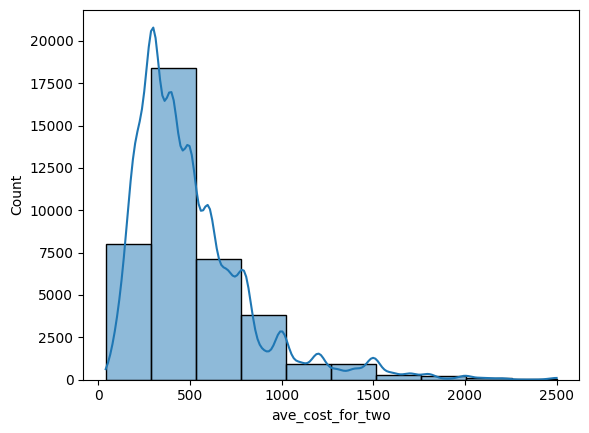

In [20]:
#Checking data distribution and skewness of Average Cost for Two variable.
sns.histplot(data=var, x='ave_cost_for_two', bins=10, kde=True)
var['ave_cost_for_two'].skew()

In [21]:
#Filling in missing numerical data with median, as the distribution is right-skewed for Average Cost for Two.
var['ave_cost_for_two'].fillna(var['ave_cost_for_two'].median(),inplace=True)

-0.7737854406271779

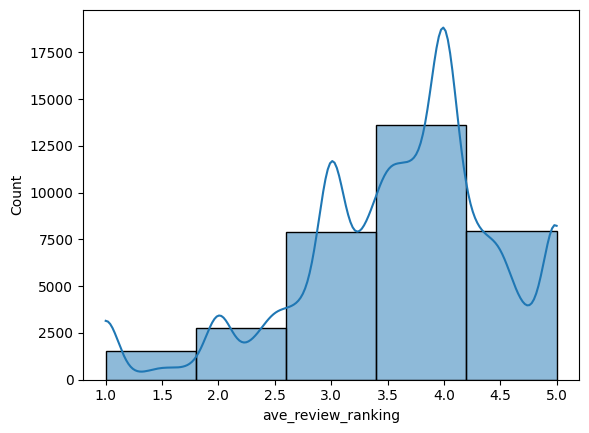

In [22]:
#Checking data distribution and skewness of Average Review Ranking variable.
sns.histplot(data=var, x='ave_review_ranking', bins=5, kde=True)
var['ave_review_ranking'].skew()

In [23]:
#Filling in missing numerical data with median, as the distribution is left-skewed for Average Review Ranking variable.
var['ave_review_ranking'].fillna(var['ave_review_ranking'].median(),inplace=True)

-0.3258660430660299

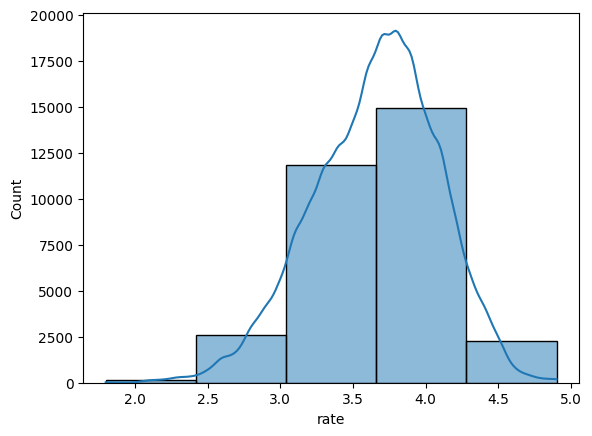

In [24]:
#Checking data distribution and skewness of Rate variable.
sns.histplot(data=var, x='rate', bins=5, kde=True)
var['rate'].skew()

In [25]:
#Filling in missing numerical data with mean, as the distribution is close to normal distribution for Rate variable.
var['rate'].fillna(var['rate'].mean(),inplace=True)

In [26]:
#Getting the null values in Descending Order
var.isnull().sum().sort_values(ascending = False)

dish_liked            22779
phone                   884
cuisines                 18
url                       0
book_table                0
book_table_N              0
online_order_N            0
rate                      0
ave_review_ranking        0
votes                     0
ave_cost_for_two          0
online_order              0
address                   0
listed_in_city            0
listed_in_type            0
menu_item                 0
rest_type                 0
location                  0
name                      0
rest_type_N               0
dtype: int64

Since dish_liked, phone and cuisines are unique and vary across restaurants, it is not feasible to replace the missing values with Mean or Median as it may lead to wrong interpretation.

### **1.2.2 Key Business Questions**


1. How many restaurants offer table booking, and what impact does it have on ratings (rate)?

In [27]:
#Number of Restaurants offering Table Booking
var['book_table'].value_counts()

No     36036
Yes     4094
Name: book_table, dtype: int64

In [28]:
#Calculating the average for Rate on the basis of Book Table values.
x = var[var["book_table"] == "Yes"]["rate"].mean()
y = var[var["book_table"] == "No"]["rate"].mean()

print("Average rating of resturant that offer table booking are : ",x)
print("Average rating of resturant that do not offer table booking are : ",y)

Average rating of resturant that offer table booking are :  4.100802111873151
Average rating of resturant that do not offer table booking are :  3.6068864524374997


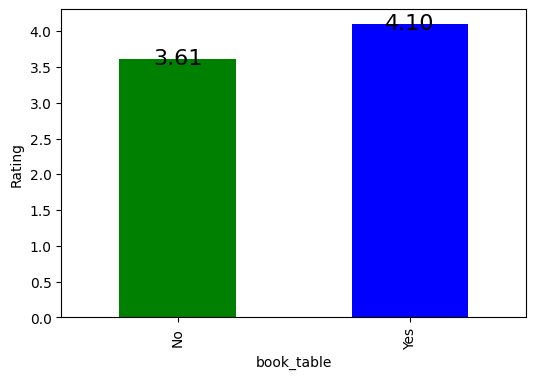

In [29]:
#Bar Plots representing Average Rating on the basis of Table Booking facility available or not.
plt.figure(figsize=(6,4))
var.groupby('book_table')['rate'].mean().plot.bar(color=['green','blue'])
plt.ylabel('Rating')

ax = plt.gca()  # Get the current Axes
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,  # You can adjust the vertical position
        f'{height:.2f}',
        ha='center',  # Horizontal alignment
        va='center',  # Vertical alignment
        fontsize=16,
        color='black'  # Text color
    )

plt.show()

<Axes: xlabel='rate', ylabel='book_table'>

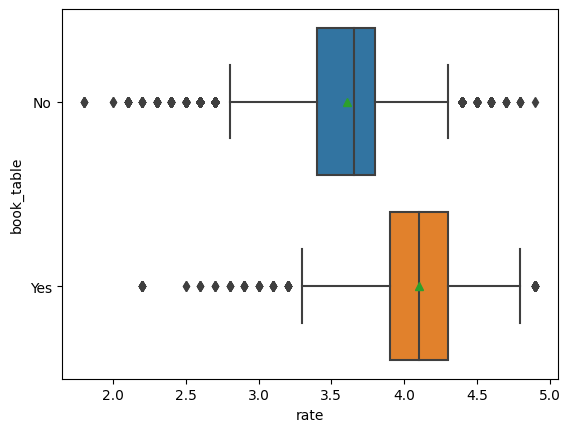

In [30]:
#Impact on Ratings with Book Table - Visualized using a Box Plot
sns.boxplot(x='rate', y='book_table', data=var, showmeans=True)

2. How many restaurants offer online ordering, and what impact does it have on ratings (rate)?

In [31]:
#Number of Restaurants offering Online Ordering
var['online_order'].value_counts()

Yes    24559
No     15571
Name: online_order, dtype: int64

In [32]:
#Calculating the average for Rate on the basis of Online Order values.
x = var[var["online_order"] == "Yes"]["rate"].mean()
y = var[var["online_order"] == "No"]["rate"].mean()

print("Average rating of resturants that offer online ordering are : ",x)
print("Average rating of resturants that do not offer online ordering are : ",y)

Average rating of resturants that offer online ordering are :  3.6885577380423777
Average rating of resturants that do not offer online ordering are :  3.607934914743027


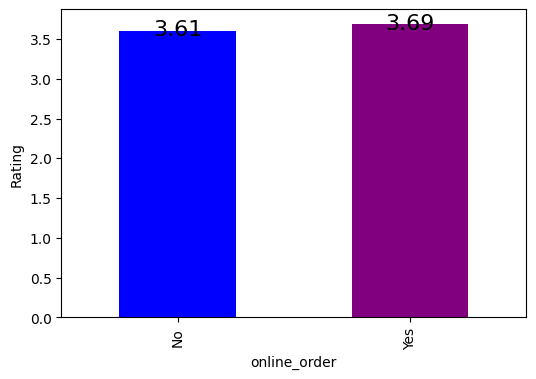

In [33]:
#Bar Plots representing Average Rating on the basis of Online Ordering facility available or not.
plt.figure(figsize=(6,4))
var.groupby('online_order')['rate'].mean().plot.bar(color=['blue','purple'])
plt.ylabel('Rating')

ax = plt.gca()  # Get the current Axes
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,  # You can adjust the vertical position
        f'{height:.2f}',
        ha='center',  # Horizontal alignment
        va='center',  # Vertical alignment
        fontsize=16,
        color='black'  # Text color
    )

plt.show()

<Axes: xlabel='rate', ylabel='online_order'>

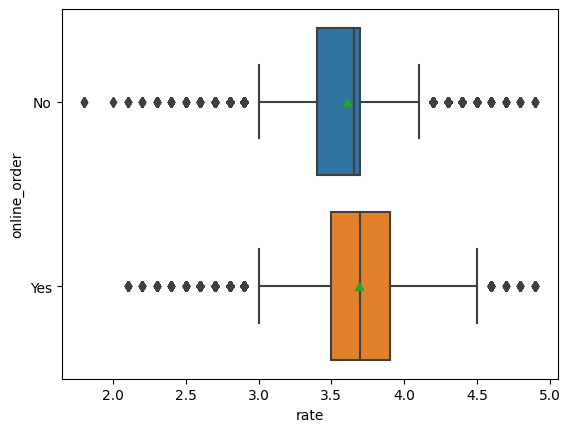

In [34]:
#Impact on Ratings - Visualized using Box Plots
sns.boxplot(x='rate', y='online_order', data=var, showmeans=True)

3. What is the effect of the average cost for two (in INR) and average customer review ranking
(ave_review_ranking in the dataset) on overall ratings (rate)?

<Axes: xlabel='rate', ylabel='ave_cost_for_two'>

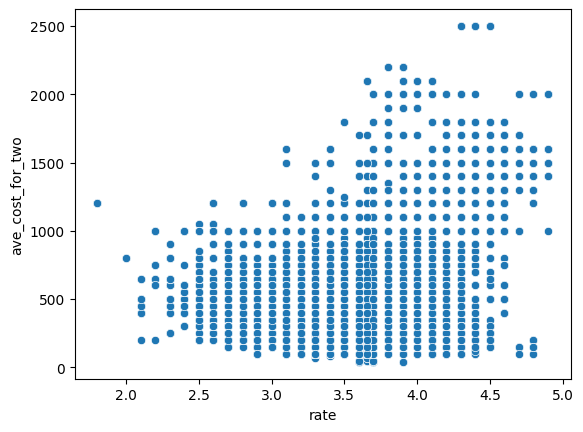

In [35]:
#Impact of Average Cost for Two on Rate - Visualized using a Scatterplot
sns.scatterplot(x='rate', y='ave_cost_for_two', data=var)

<Axes: xlabel='rate', ylabel='ave_review_ranking'>

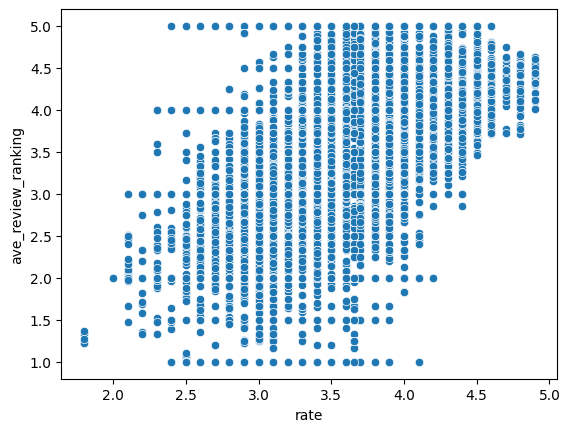

In [36]:
#Impact of Average Customer Review Ranking on Rate - Visualized using a Scatterplot
sns.scatterplot(x='rate', y='ave_review_ranking', data=var)

4. How do ratings (rate) and average cost for two vary among the restaurant types?

<Axes: xlabel='rate', ylabel='rest_type'>

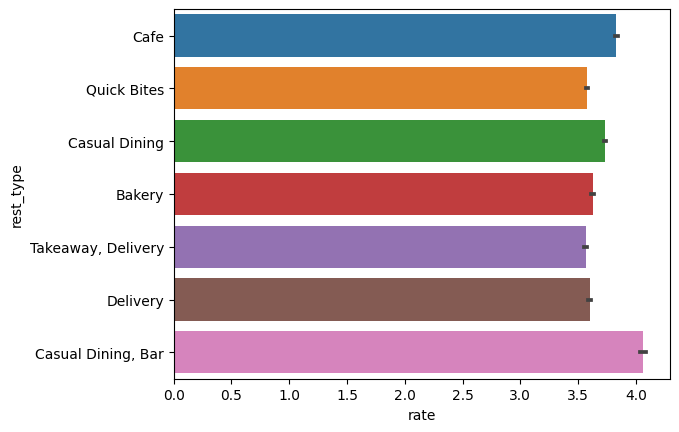

In [37]:
#Impact of Rate according to Restaurant Types - Visualized using Bar Plots
sns.barplot(x='rate', y='rest_type', data=var)

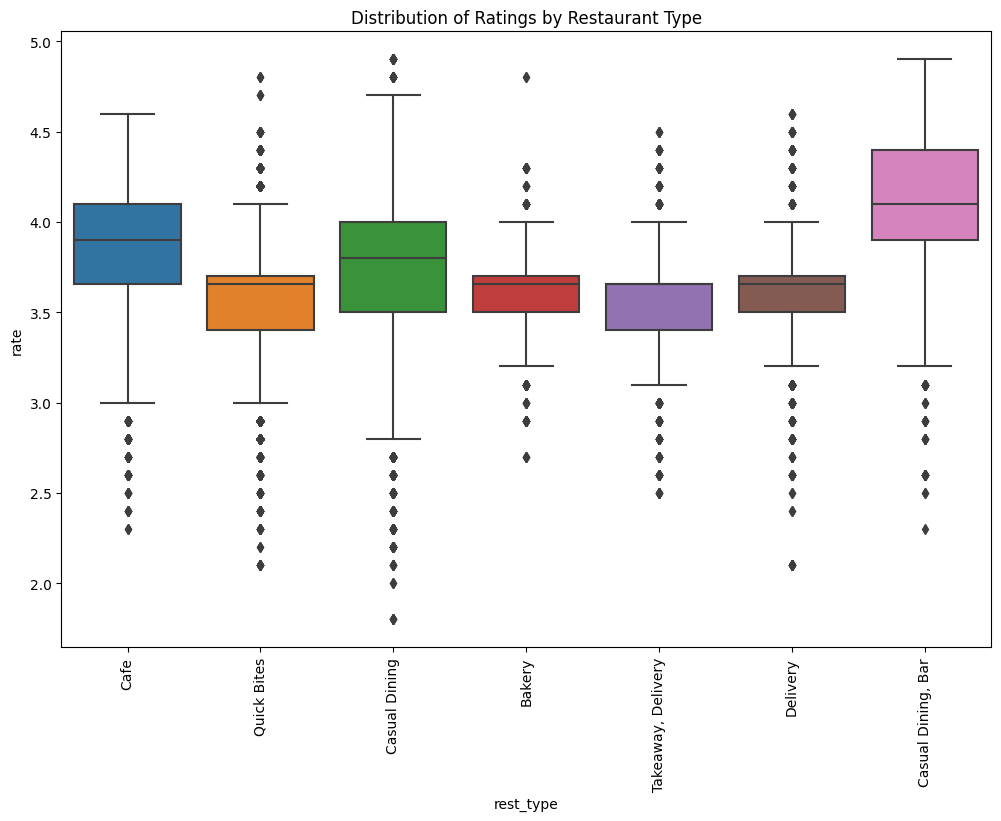

In [38]:
#Distribution of Ratings against Restaurant Type - Visualized using a Boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='rest_type', y='rate', data=var)
plt.xticks(rotation=90)
plt.title('Distribution of Ratings by Restaurant Type')
plt.show()

<Axes: xlabel='ave_cost_for_two', ylabel='rest_type'>

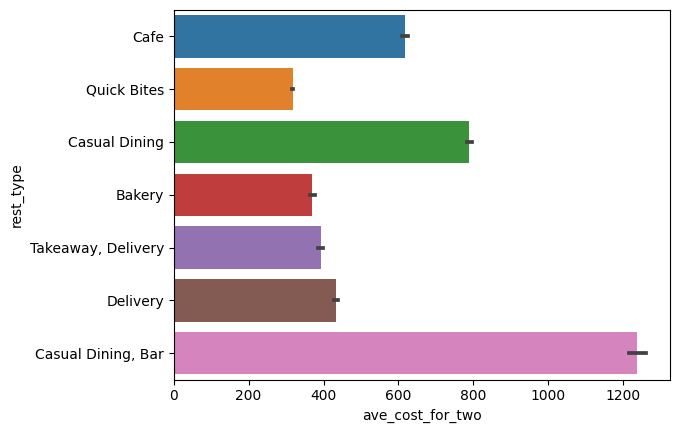

In [39]:
#Impact of Average Cost for Two according to Restaurant types - Visualized using a Bar Plot
sns.barplot(x='ave_cost_for_two', y='rest_type', data=var)

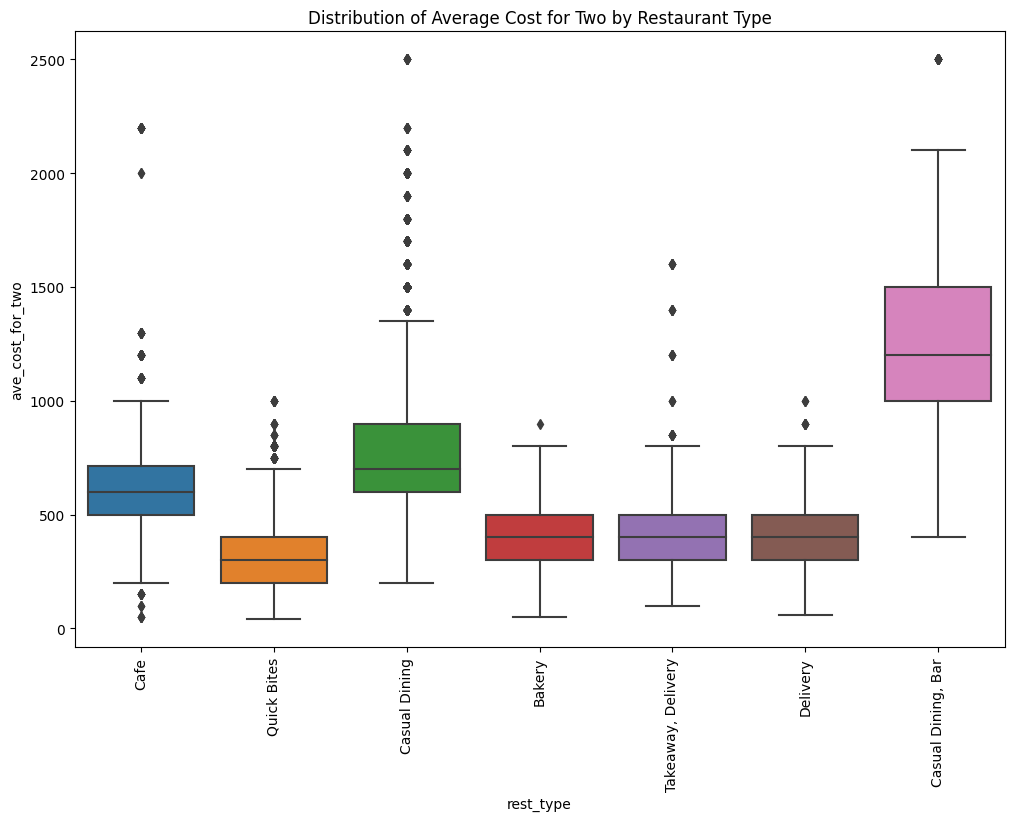

In [40]:
#Distribution of Ratings against Average Cost for Two - Visualized using a Boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='rest_type', y='ave_cost_for_two', data=var)
plt.xticks(rotation=90)
plt.title('Distribution of Average Cost for Two by Restaurant Type')
plt.show()

5. Any additional insights about the restaurants, cities, and cuisines; for example, but not necessarily,
what are the best- or worst- performing restaurants, or which city has the greatest number of
restaurants?

In [41]:
#Top 10 Worst Performing Restaurants on the basis of Average Review Ranking and Votes
worst_performing_restaurants = var.sort_values(by=['ave_review_ranking', 'votes'], ascending=[True, True]).head(10)
print("Top 10 Worst-Performing Restaurants:")
print(worst_performing_restaurants[['name', 'ave_review_ranking', 'votes']])

Top 10 Worst-Performing Restaurants:
                                  name  ave_review_ranking  votes
42    Tiwari's Ghee Paratha And Chaats                 1.0      0
115                  Burger Bite House                 1.0      0
145                            Virgins                 1.0      0
207            Chickpete Donne Biryani                 1.0      0
356              Chawla's 2 Online.com                 1.0      0
490                        Masale Daan                 1.0      0
538                         Omleterian                 1.0      0
599                        Bakery 24x7                 1.0      0
686                         Food Court                 1.0      0
1009                      Xpress Dhaba                 1.0      0


In [42]:
#Top 10 Best Performing Restaurants on the basis of Average Review Ranking and Votes
best_performing_restaurants = var.sort_values(by=['ave_review_ranking', 'votes'], ascending=[False, False]).head(10)
print("\nTop 10 Best-Performing Restaurants:")
print(best_performing_restaurants[['name', 'ave_review_ranking', 'votes']])


Top 10 Best-Performing Restaurants:
                    name  ave_review_ranking  votes
27467          Pizza Hut                 5.0    693
40103          Pizza Hut                 5.0    693
10132        The Orchard                 5.0    672
34817        The Orchard                 5.0    672
6372   Shuddh Desi Khana                 5.0    598
7046   Shuddh Desi Khana                 5.0    597
31522  Shuddh Desi Khana                 5.0    597
16466   BOX8- Desi Meals                 5.0    571
498     Marwa Restaurant                 5.0    551
2190    Marwa Restaurant                 5.0    551


In [43]:
#City having the greatest number of restaurants
city_with_most_restaurants = var['listed_in_city'].value_counts().idxmax()
num_restaurants_in_city = var['listed_in_city'].value_counts().max()
print(f"\nThe city with the greatest number of restaurants is {city_with_most_restaurants} with {num_restaurants_in_city} restaurants.")


The city with the greatest number of restaurants is BTM with 2618 restaurants.


In [44]:
#Count of restaurants in each city.
var['listed_in_city'].value_counts()

BTM                      2618
Koramangala 7th Block    2309
Koramangala 5th Block    2237
Koramangala 4th Block    2202
Koramangala 6th Block    2082
Jayanagar                1889
JP Nagar                 1674
HSR                      1432
Indiranagar              1357
Marathahalli             1353
Bannerghatta Road        1297
Church Street            1290
MG Road                  1275
Lavelle Road             1261
Brigade Road             1234
Brookefield              1216
Whitefield               1190
Residency Road           1147
Kammanahalli             1100
Kalyan Nagar             1084
Old Airport Road         1054
Electronic City          1037
Basavanagudi             1027
Sarjapur Road             965
Frazer Town               941
Bellandur                 929
Malleshwaram              810
Rajajinagar               800
Banashankari              714
New BEL Road              606
Name: listed_in_city, dtype: int64

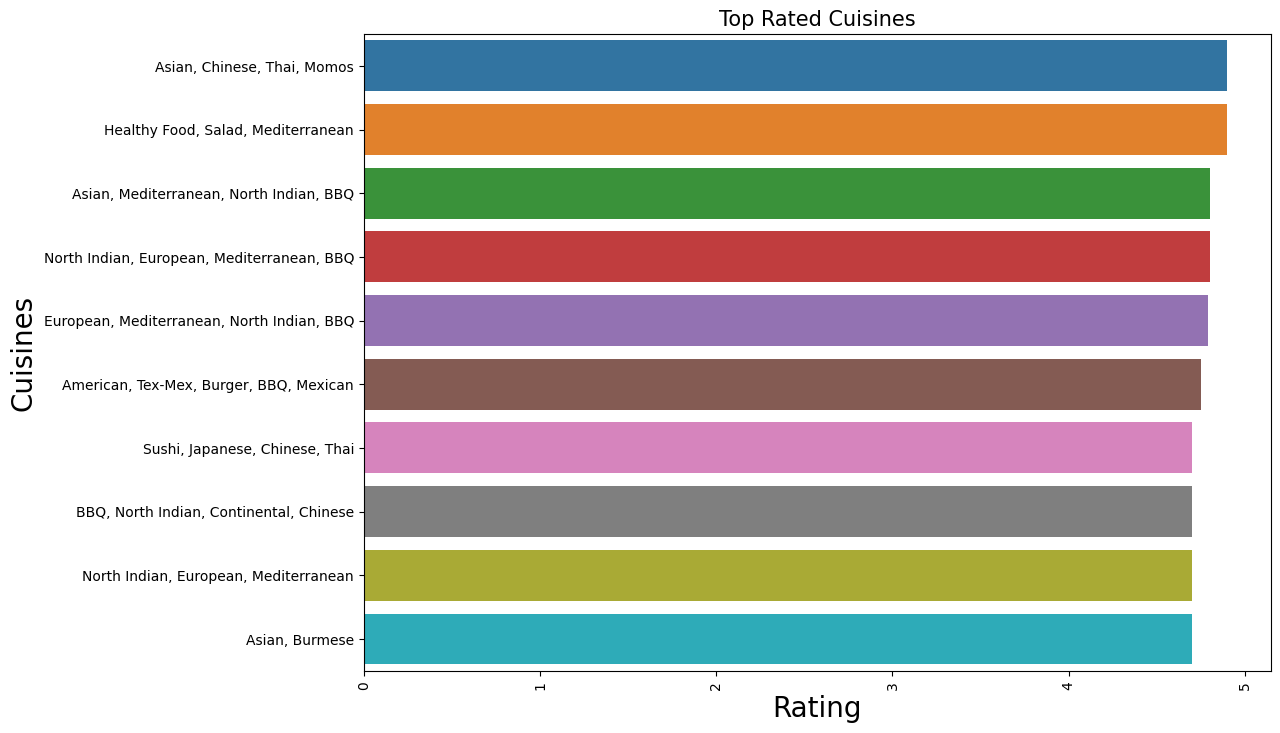

In [45]:
# Top 10 Highest Rated cuisines - Visualized using a Bar Plot

# Group by cuisines and calculate the average rating
Cuisine_Rating = var.groupby(['cuisines'], as_index=False)['rate'].mean()

# Sort the cuisines by rating in descending order and select the top 10
Top_Ratings = Cuisine_Rating.sort_values(['rate'], ascending=False).head(10)

# Set the figure size
plt.figure(figsize=(11.7, 8.27))

# Create a bar plot
sns.barplot(x='rate', y='cuisines', data=Top_Ratings)
plt.title('Top Rated Cuisines', fontsize=15)
plt.xlabel('Rating', fontsize=20)
plt.ylabel('Cuisines', fontsize=20)
plt.xticks(rotation=90)
plt.show()

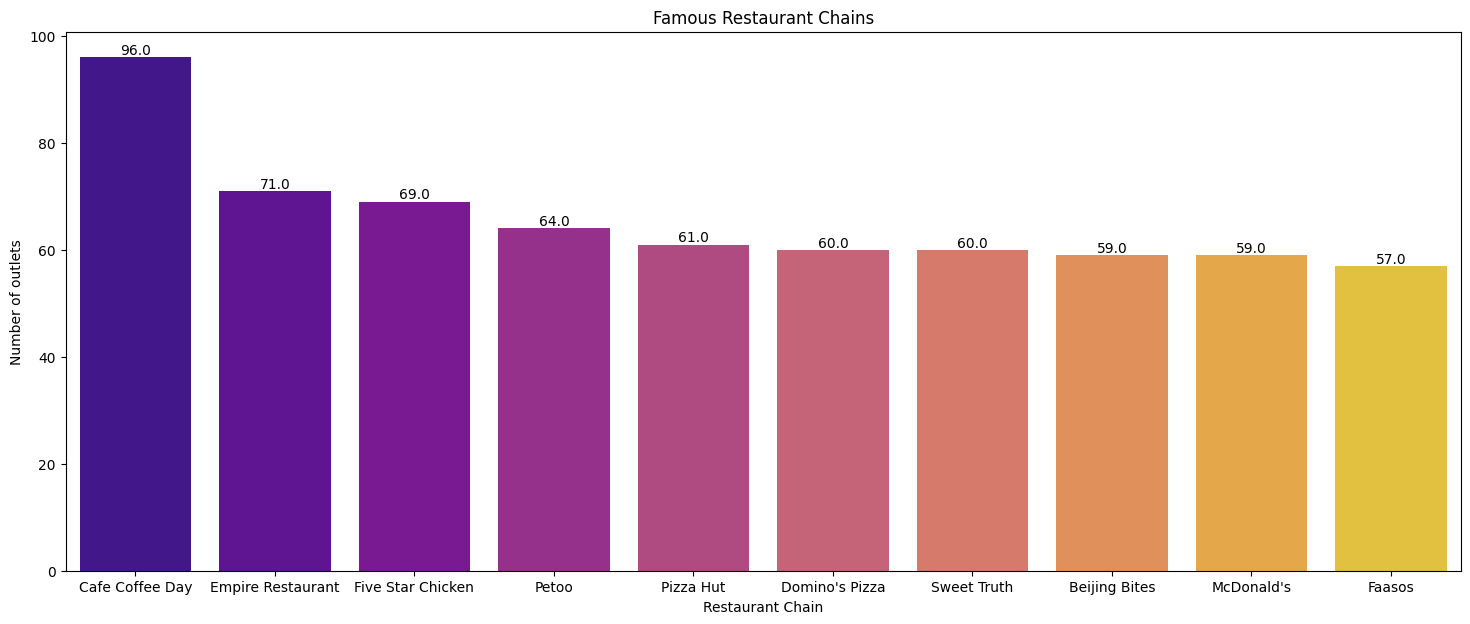

In [46]:
#Most Famous Resturant Chains - Visualized using a barplot

top_rest_chains = var['name'].value_counts()
top_rest_chains = top_rest_chains.sort_values(ascending=False).head(10)

plt.figure(figsize=(18,7))
ax=sns.barplot(x=top_rest_chains.index, y=top_rest_chains.values, palette = 'plasma')
plt.title("Famous Restaurant Chains")
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')
plt.xlabel("Restaurant Chain")
plt.ylabel("Number of outlets")
plt.show()

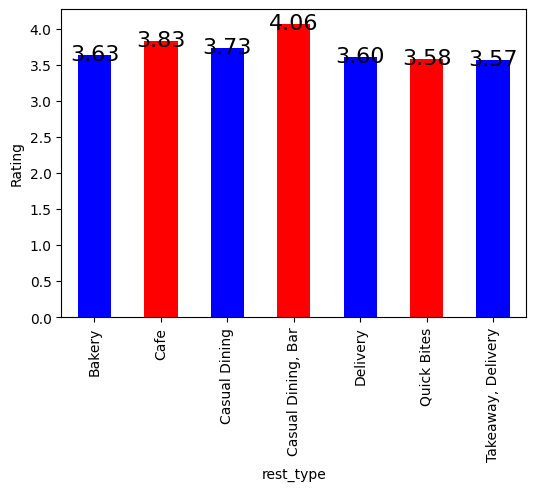

In [47]:
#Average Ratings by each Restaurant Type - Visualized using a barplot
plt.figure(figsize=(6,4))
var.groupby('rest_type')['rate'].mean().plot.bar(color=['blue','red'])
plt.ylabel('Rating')

ax = plt.gca()  # Get the current Axes
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,  # You can adjust the vertical position
        f'{height:.2f}',
        ha='center',  # Horizontal alignment
        va='center',  # Vertical alignment
        fontsize=16,
        color='black'  # Text color
    )

plt.show()

## **1.3 Exploratory Data Analysis**

###**1.3.1 Univariate Analysis**

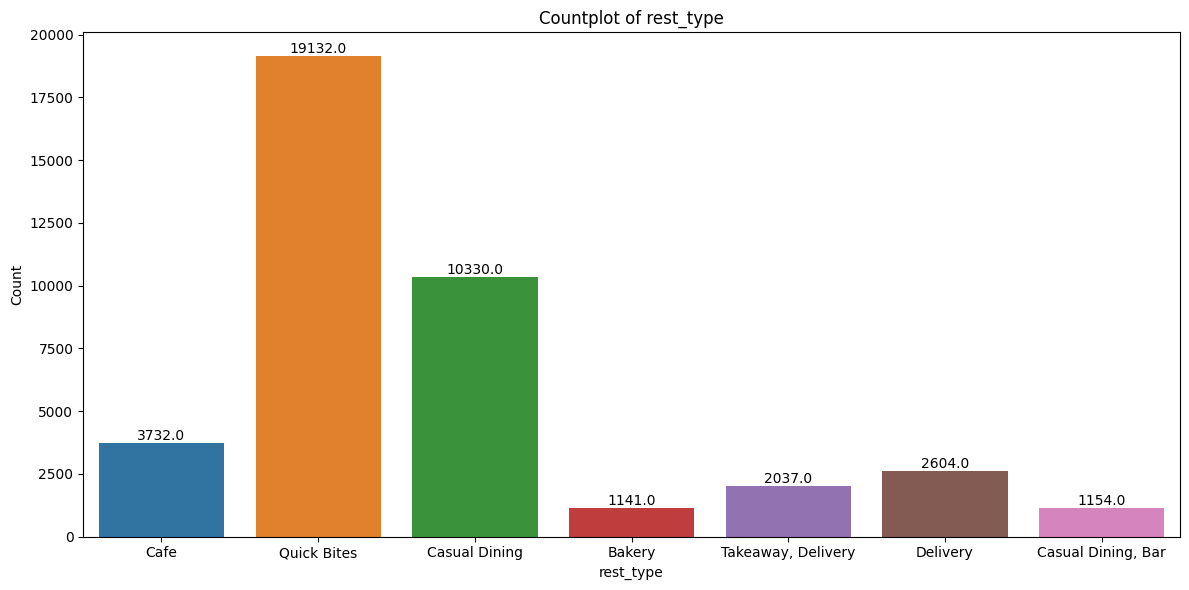

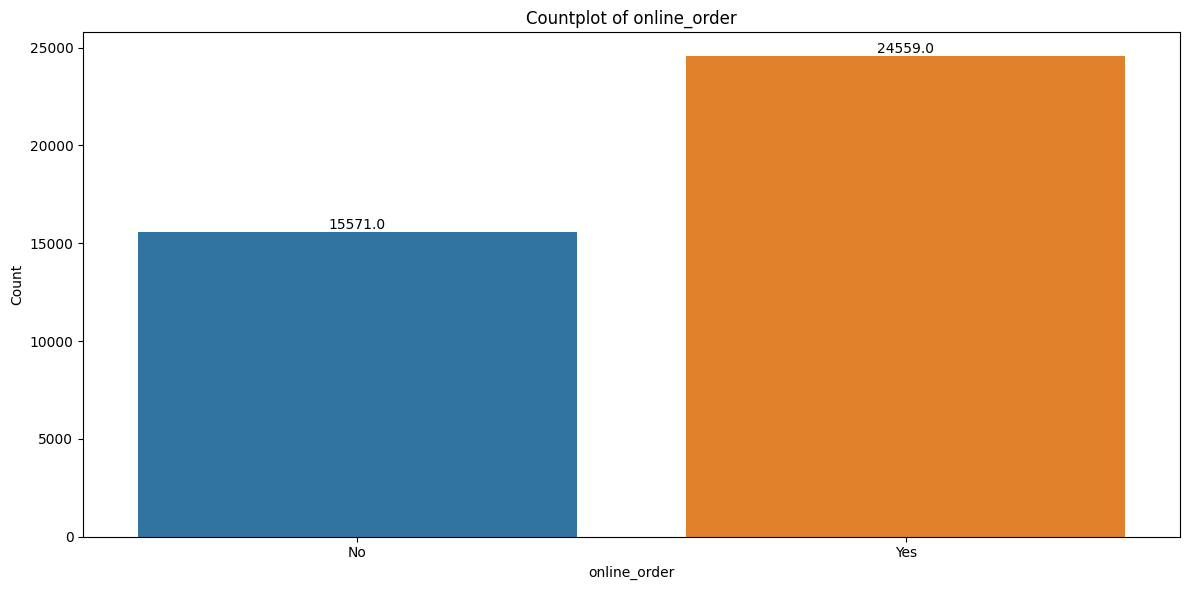

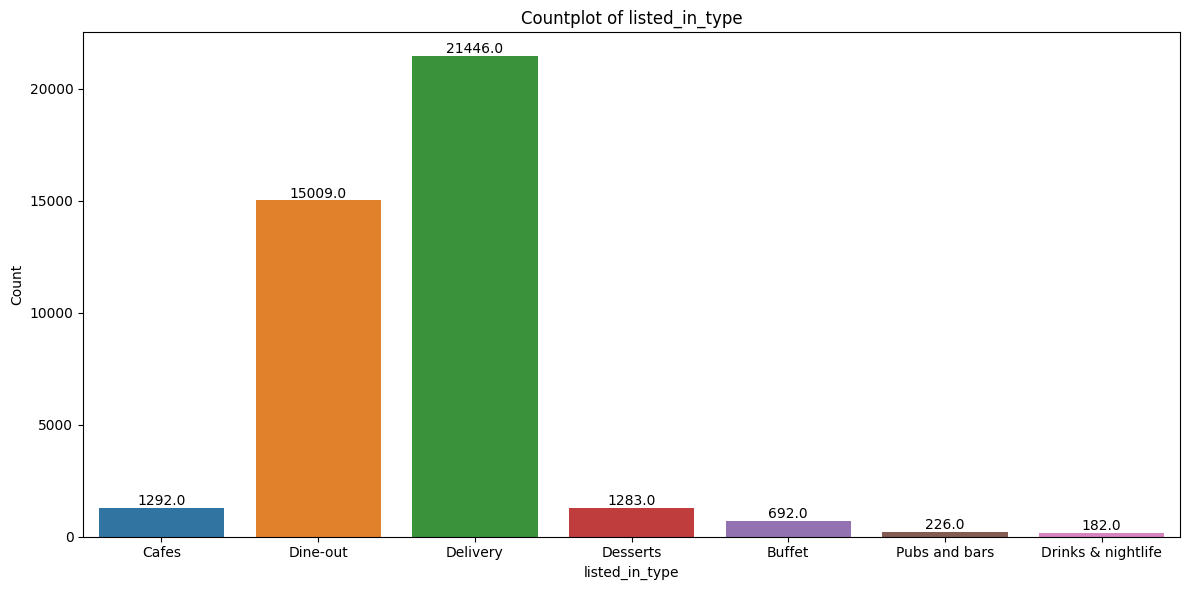

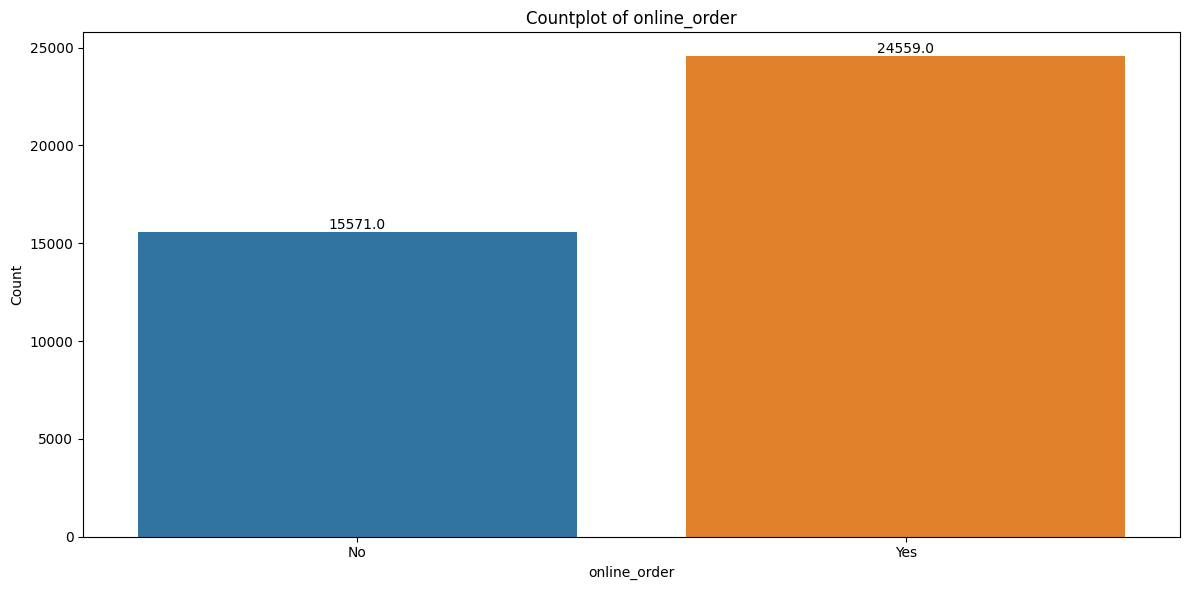

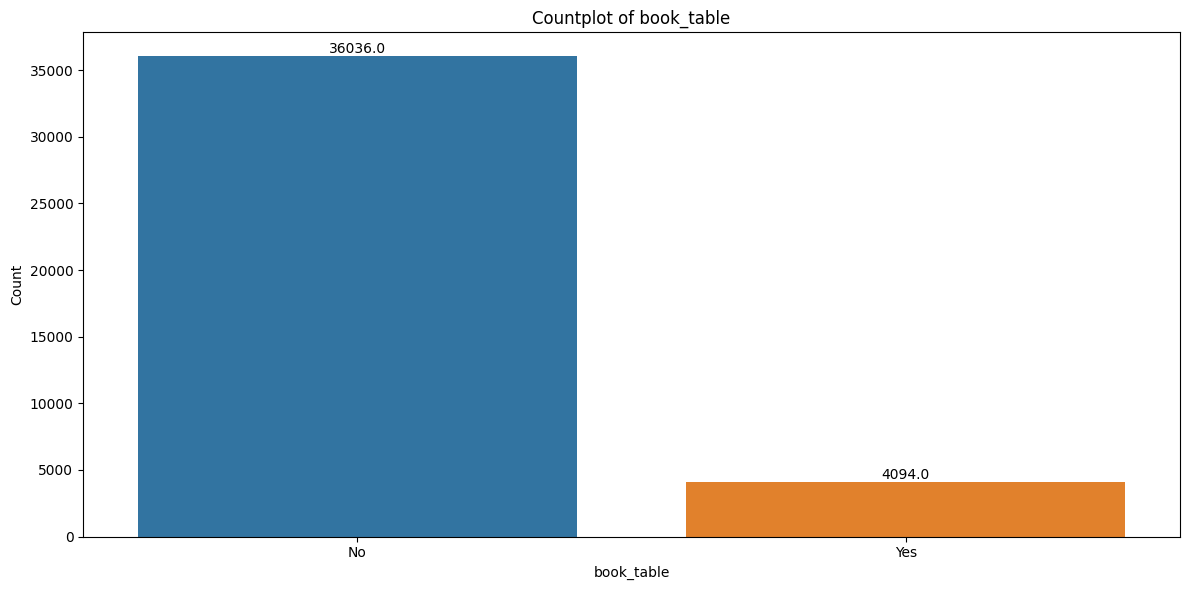

In [48]:
#Plotting Countplots for the below mentioned categorical variables.
categorical_variables = ['rest_type', 'online_order', 'listed_in_type', 'online_order', 'book_table']

for i in categorical_variables:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(x=var[i])

    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

    plt.title(f'Countplot of {i}')
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

count    40130.000000
mean         3.657275
std          0.383746
min          1.800000
25%          3.500000
50%          3.657275
75%          3.900000
max          4.900000
Name: rate, dtype: float64




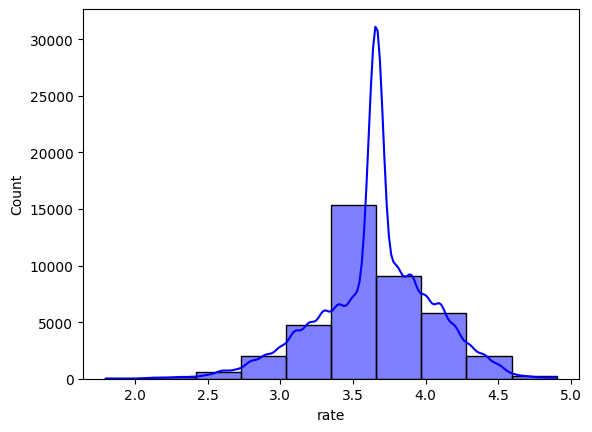

count    40130.000000
mean         3.610388
std          0.839315
min          1.000000
25%          3.200000
50%          3.727273
75%          4.000000
max          5.000000
Name: ave_review_ranking, dtype: float64




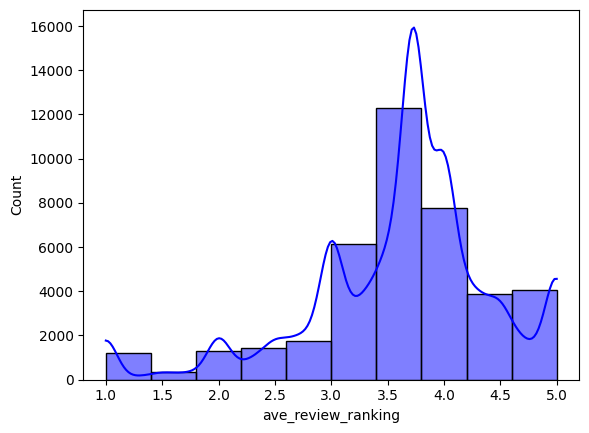

count    40130.000000
mean       225.685547
std        598.568781
min          0.000000
25%          6.000000
50%         36.000000
75%        174.000000
max      12121.000000
Name: votes, dtype: float64




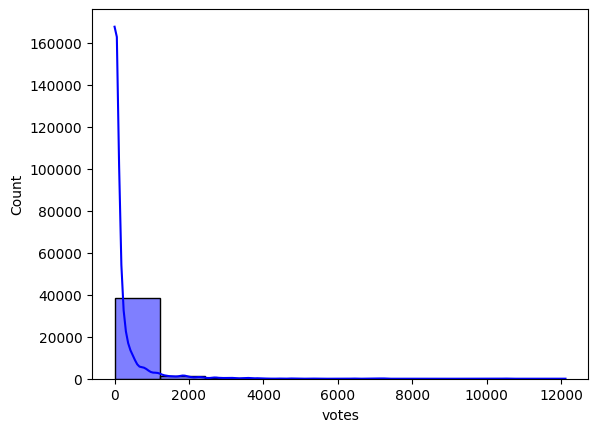

count    40130.000000
mean       506.059183
std        323.298238
min         40.000000
25%        300.000000
50%        400.000000
75%        600.000000
max       2500.000000
Name: ave_cost_for_two, dtype: float64




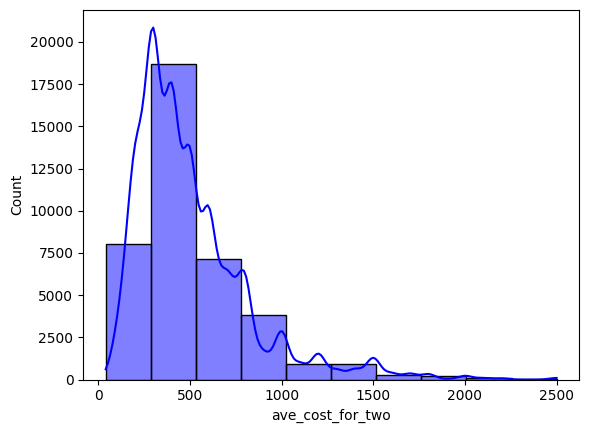

In [49]:
#In this code, the loop iterates through each numerical variable in numerical_variables.
#For each variable, a Histogram with Kernel Density Estimate is created using sns.histplot() with kde = True as parameter.

numerical_variables = ['rate', 'ave_review_ranking', 'votes', 'ave_cost_for_two']

for i in numerical_variables:
    print(var[i].describe())
    print('\n')
    plt.figure()
    ax = sns.histplot(data=var, x=i, bins=10, kde=True, color='blue', edgecolor='black')
    plt.show()

count    40130.000000
mean         3.657275
std          0.383746
min          1.800000
25%          3.500000
50%          3.657275
75%          3.900000
max          4.900000
Name: rate, dtype: float64




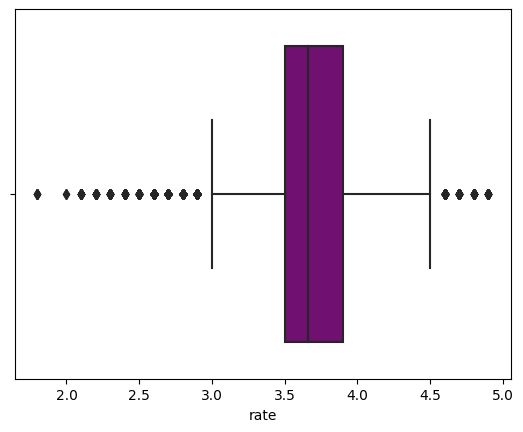

count    40130.000000
mean         3.610388
std          0.839315
min          1.000000
25%          3.200000
50%          3.727273
75%          4.000000
max          5.000000
Name: ave_review_ranking, dtype: float64




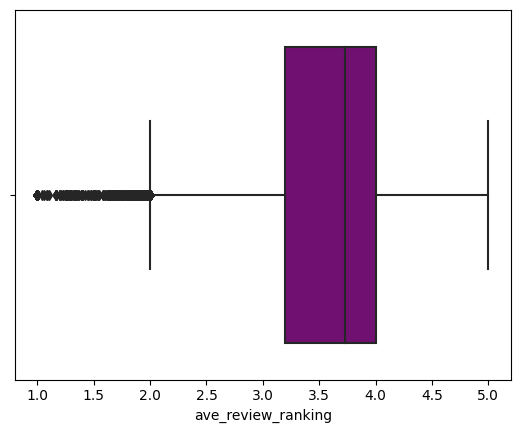

count    40130.000000
mean       225.685547
std        598.568781
min          0.000000
25%          6.000000
50%         36.000000
75%        174.000000
max      12121.000000
Name: votes, dtype: float64




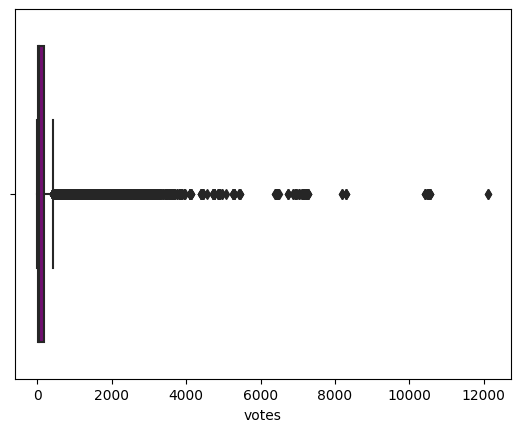

count    40130.000000
mean       506.059183
std        323.298238
min         40.000000
25%        300.000000
50%        400.000000
75%        600.000000
max       2500.000000
Name: ave_cost_for_two, dtype: float64




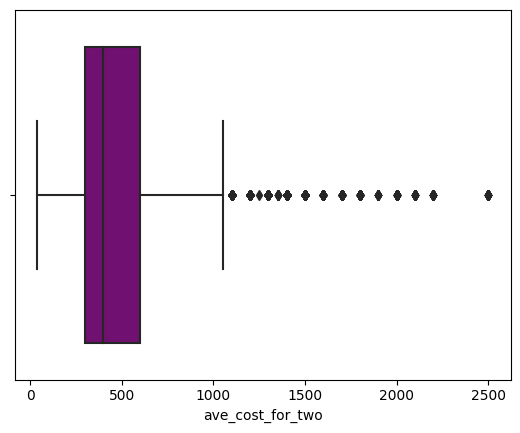

In [50]:
#In this code, the loop iterates through each numerical variable in numerical_variables.
#For each variable, a Boxplot is created using sns.boxplot().

numerical_variables = ['rate', 'ave_review_ranking', 'votes', 'ave_cost_for_two']

for i in numerical_variables:
    print(var[i].describe())
    print('\n')
    plt.figure()
    ax = sns.boxplot(data=var, x=i, color='purple')
    plt.show()


count    40130.000000
mean         3.610388
std          0.839315
min          1.000000
25%          3.200000
50%          3.727273
75%          4.000000
max          5.000000
Name: ave_review_ranking, dtype: float64

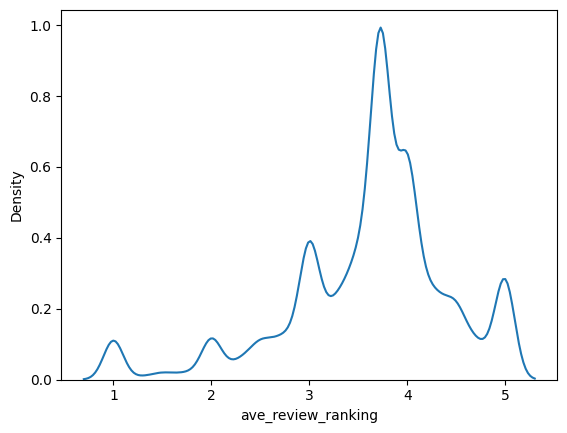

In [51]:
#Kernel Density Estimate Plot is created for the Average Review Ranking variable.
sns.kdeplot(x='ave_review_ranking', data=var)
var['ave_review_ranking'].describe()

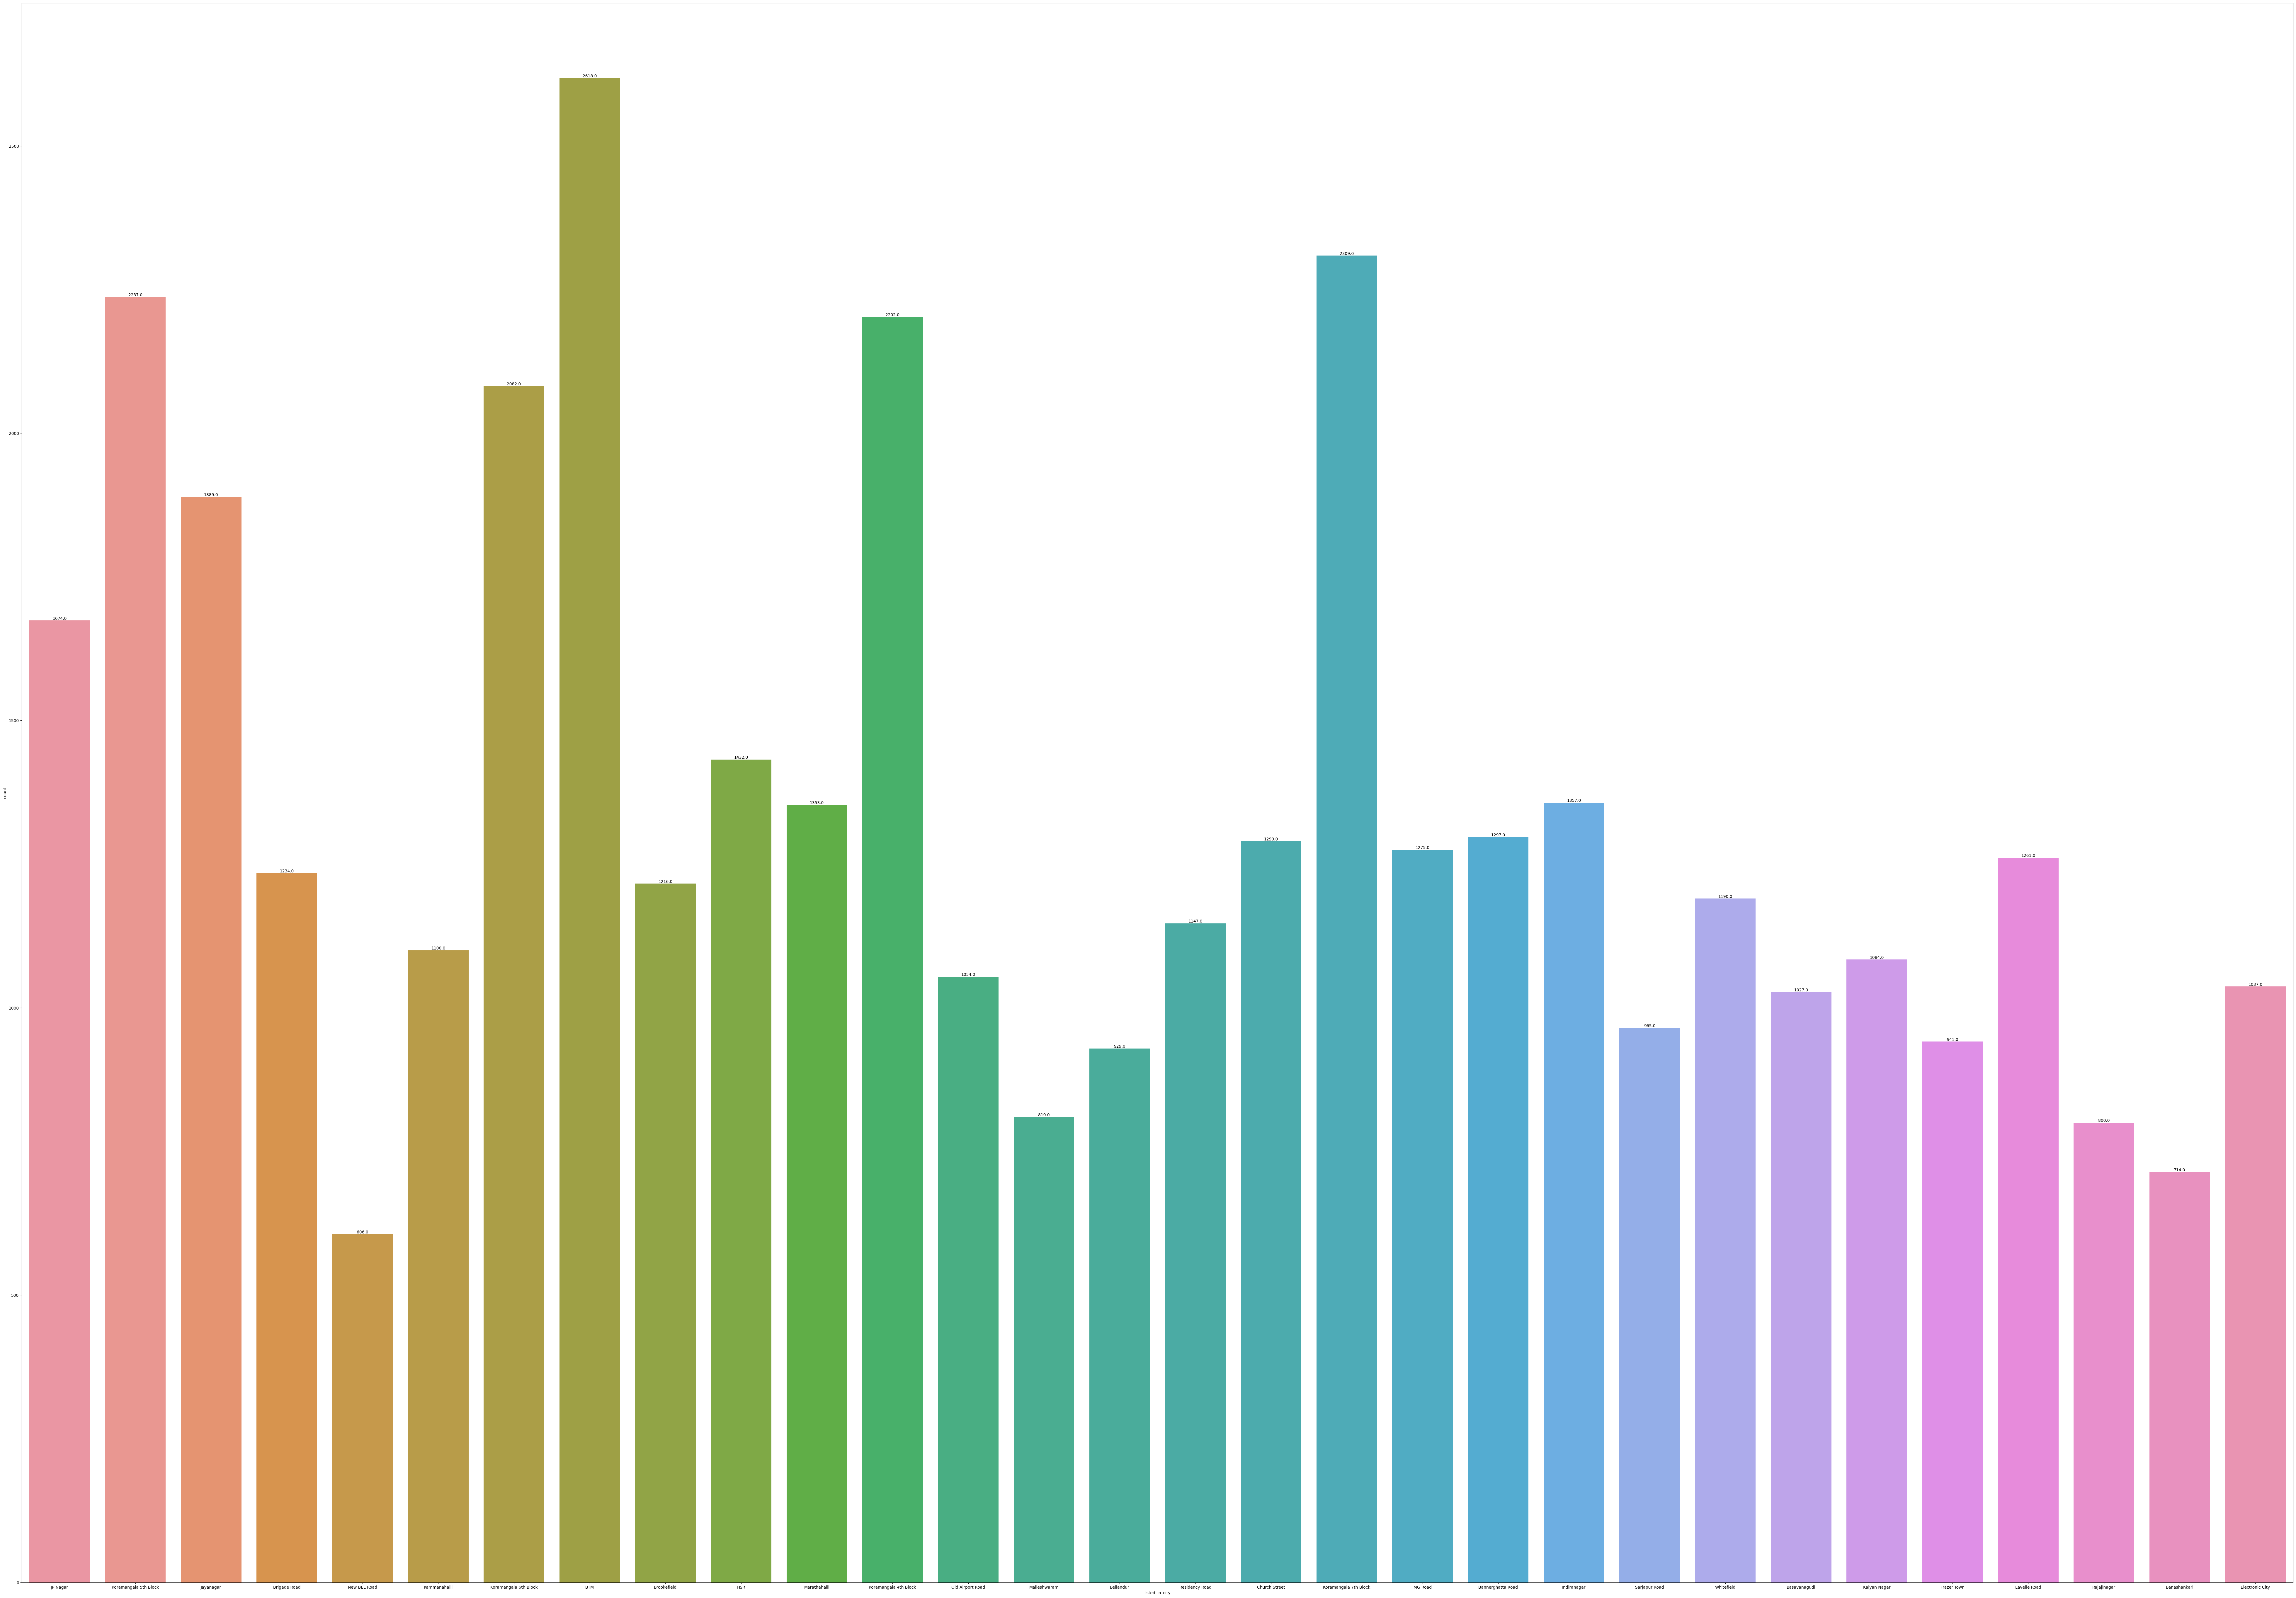

In [52]:
#Countplot of Listed in City variable.
plt.figure(figsize=(100, 70))
ax= sns.countplot(x=var['listed_in_city'])

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.show()

###**1.3.2 Bivariate Analysis**

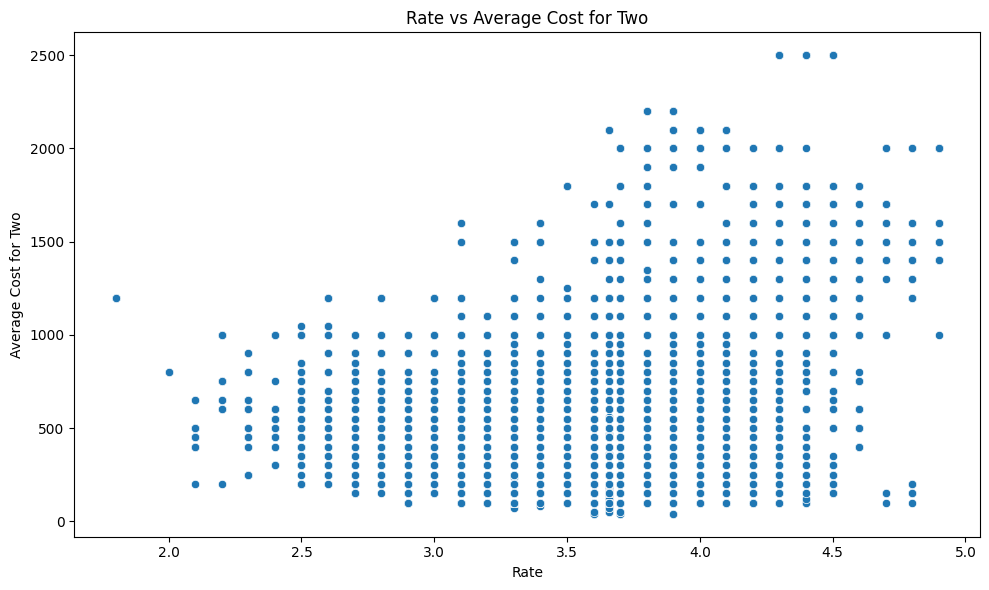

In [53]:
#Plotting a Scatterplot between Rate and Average Cost for Two
plt.figure(figsize=(10, 6))  # Adjust the figure size for better readability

# Create the scatterplot
ax = sns.scatterplot(data=var, x='rate', y='ave_cost_for_two')

plt.title('Rate vs Average Cost for Two')
plt.xlabel('Rate')
plt.ylabel('Average Cost for Two')
plt.tight_layout()  # Ensures proper spacing between elements
plt.show()

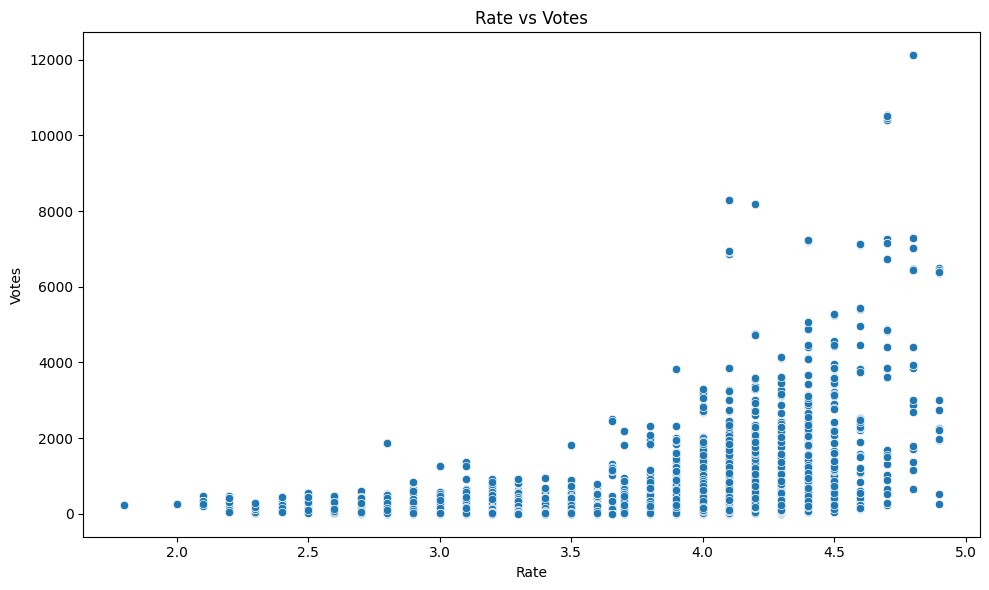

In [54]:
#Plotting a Scatterplot between Rate and Votes
plt.figure(figsize=(10, 6))  # Adjust the figure size for better readability

# Create the scatterplot
ax = sns.scatterplot(data=var, x='rate', y='votes')

plt.title('Rate vs Votes')
plt.xlabel('Rate')
plt.ylabel('Votes')
plt.tight_layout()  # Ensures proper spacing between elements
plt.show()

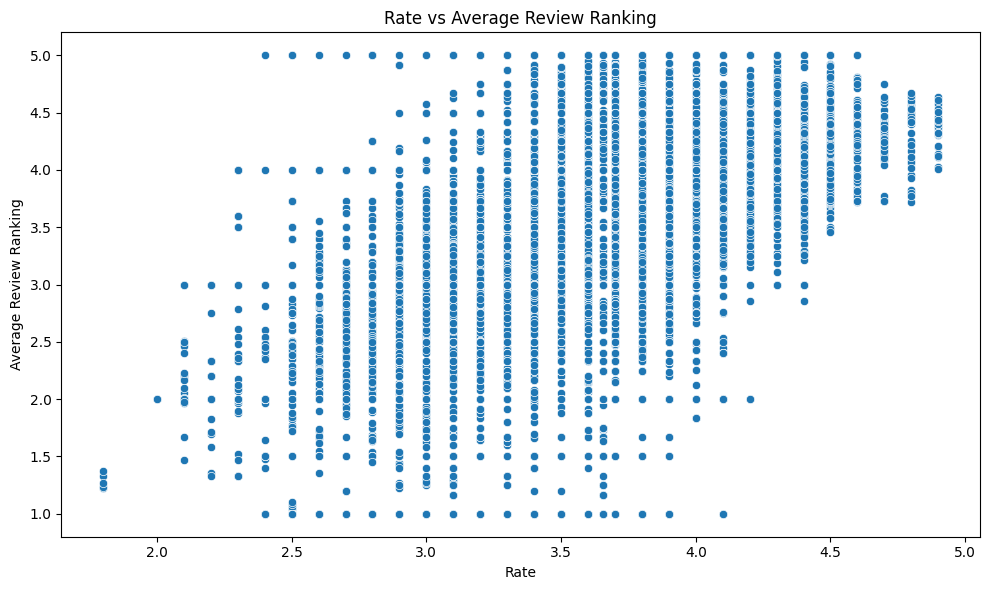

In [55]:
#Plotting a Scatterplot between Rate and Average Review Ranking
plt.figure(figsize=(10, 6))  # Adjust the figure size for better readability

# Create the scatterplot
ax = sns.scatterplot(data=var, x='rate', y='ave_review_ranking')

plt.title('Rate vs Average Review Ranking')
plt.xlabel('Rate')
plt.ylabel('Average Review Ranking')
plt.tight_layout()  # Ensures proper spacing between elements
plt.show()

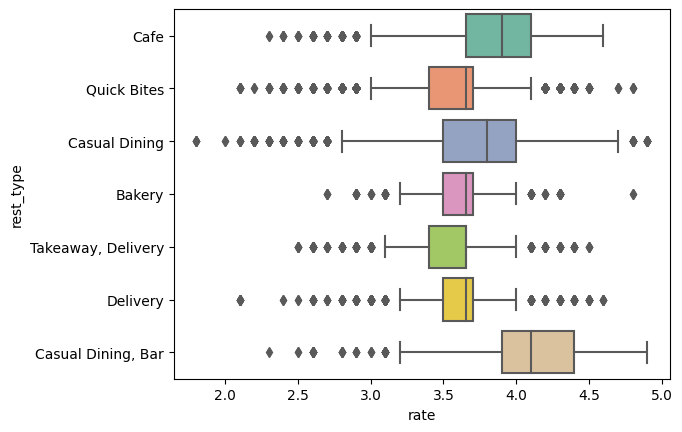

In [56]:
#Plotting a Boxplot between Rate and Restaurant Type
sns.boxplot(data=var, x='rate', y='rest_type',palette='Set2')
plt.show()

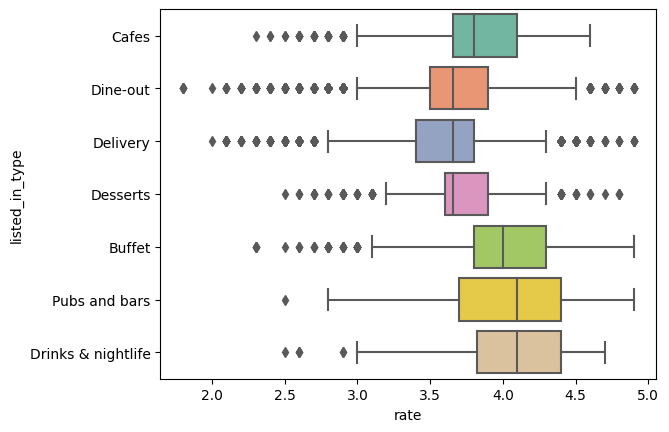

In [57]:
#Plotting a Boxplot between Rate and Restaurant Type
sns.boxplot(data=var, x='rate', y='listed_in_type', palette='Set2')
plt.show()

<Axes: xlabel='ave_cost_for_two', ylabel='rate'>

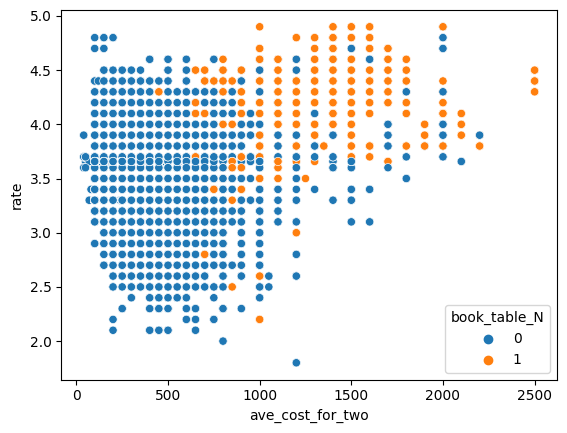

In [58]:
#Plotting a Scatterplot between Average Cost for Two and Rate with Hue as Book Table
sns.scatterplot(data=var, x='ave_cost_for_two', y='rate', hue='book_table_N')

<Axes: xlabel='ave_cost_for_two', ylabel='rate'>

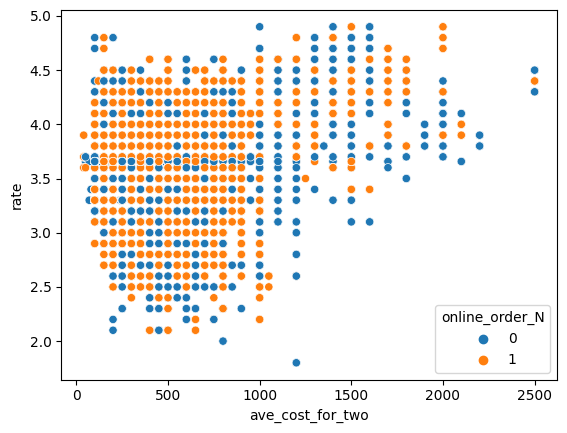

In [59]:
#Plotting a Scatterplot between Average Cost for Two and Rate with Hue as Online Order
sns.scatterplot(data=var, x='ave_cost_for_two', y='rate', hue='online_order_N')

###**1.3.3 Multivariate Analysis**

<ipython-input-60-0be99c33eedd>:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(var.corr(), cmap="crest", square=True, annot=True, fmt=".2f")


<Axes: >

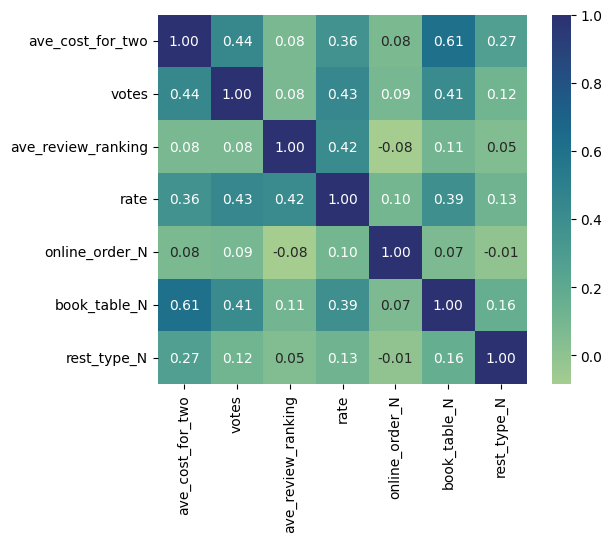

In [60]:
#We are plotting a correlation heatmap for all the numerical variables in order to determine the variables that are highly correlated to rate,
#which will allow us further for specific feature selection in order to train our model using various algorithms.

sns.heatmap(var.corr(), cmap="crest", square=True, annot=True, fmt=".2f")

### **1.3.4 Dropping Columns which are not relevant to our analysis**

In [61]:
#Dropping the Columns mentioned below. Since they are non-numerical, have many unique values and some have missing values as well which makes it difficult to encode to convert it to numerical format.
var = var.drop(['url', 'address', 'name', 'phone', 'location', 'cuisines', 'menu_item', 'listed_in_city', 'dish_liked'], axis=1)
var.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40130 entries, 0 to 40129
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rest_type           40130 non-null  object 
 1   listed_in_type      40130 non-null  object 
 2   online_order        40130 non-null  object 
 3   book_table          40130 non-null  object 
 4   ave_cost_for_two    40130 non-null  float64
 5   votes               40130 non-null  int64  
 6   ave_review_ranking  40130 non-null  float64
 7   rate                40130 non-null  float64
 8   online_order_N      40130 non-null  int64  
 9   book_table_N        40130 non-null  int64  
 10  rest_type_N         40130 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 3.4+ MB


##**2.1 Linear Regression**


### **2.1.1 Selecting Features**

<ipython-input-62-be330926de5b>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(var.corr(), annot=True, cmap='Blues')


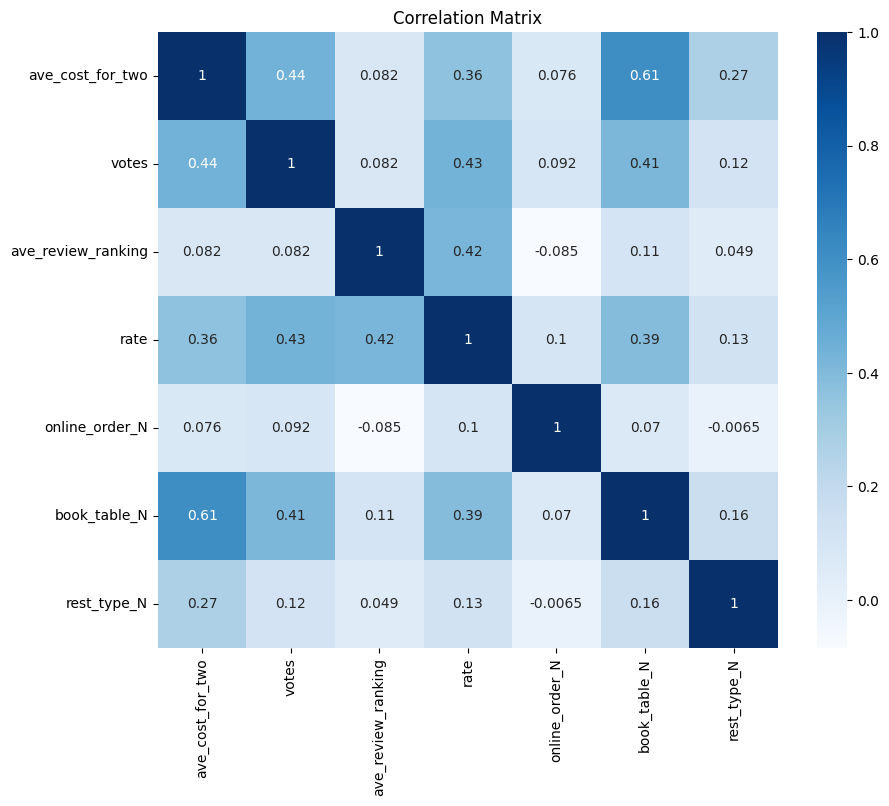

In [62]:
#Plotting a Correlation Heatmap before Feature Selection
plt.figure(figsize=(10, 8))
sns.heatmap(var.corr(), annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

In [63]:
#Prints the number of columns along with its data type.
var.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40130 entries, 0 to 40129
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rest_type           40130 non-null  object 
 1   listed_in_type      40130 non-null  object 
 2   online_order        40130 non-null  object 
 3   book_table          40130 non-null  object 
 4   ave_cost_for_two    40130 non-null  float64
 5   votes               40130 non-null  int64  
 6   ave_review_ranking  40130 non-null  float64
 7   rate                40130 non-null  float64
 8   online_order_N      40130 non-null  int64  
 9   book_table_N        40130 non-null  int64  
 10  rest_type_N         40130 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 3.4+ MB


In [64]:
#Selecting Relevant features to train and evaluate a model.
features=['ave_cost_for_two', 'votes', 'ave_review_ranking', 'book_table_N']
X=var[features]

In [65]:
#Specify the label/target variable.
y=var['rate']
y.head()

0    3.6
1    3.8
2    3.9
3    4.3
4    3.7
Name: rate, dtype: float64

###**2.1.1 Split Data**

In [66]:
# Splitting dataset into training set (70%) and test set (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2023)

#inspect the split datasets
print(X_train.head())
print(y_train.head())

print('Training dataset size:',X_train.shape)
print('Test dataset size:',X_test.shape)

       ave_cost_for_two  votes  ave_review_ranking  book_table_N
18823             400.0    173            3.174352             0
32458             750.0     17            2.000000             0
5938              600.0      0            3.000000             0
30830             300.0      5            4.500000             0
15503             850.0    864            3.800000             1
18823    3.700000
32458    3.400000
5938     3.657275
30830    3.400000
15503    4.000000
Name: rate, dtype: float64
Training dataset size: (28091, 4)
Test dataset size: (12039, 4)


###**2.1.2. Train a linear model**

In [67]:
#Create a linear_model object
reg = linear_model.LinearRegression()

In [68]:
#Training a Regression model (regressor) with the training dataset
reg=reg.fit(X_train, y_train)

### **2.1.3 Make predictions**
Make predictions using the model and the test set

In [69]:
#Make predictions for the test dataset
y_pred = reg.predict(X_test)

**Inspect the predictions and the original labels**

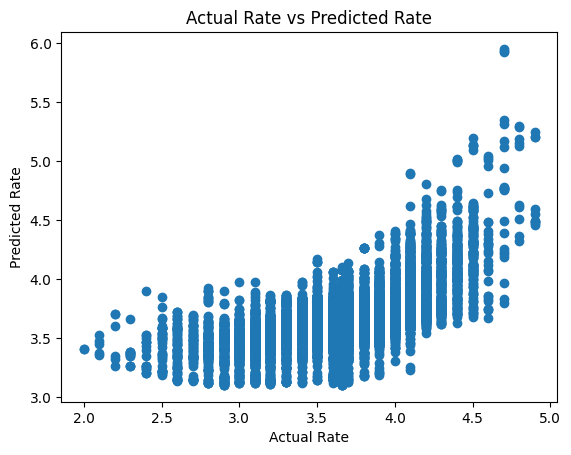

In [70]:
#Plotting a Scatterplot between Actual Rate and Predicted Rate
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rate")
plt.ylabel("Predicted Rate")
plt.title("Actual Rate vs Predicted Rate")
plt.show()

In [71]:
#set the formatting for floating numbers
pd.set_option('display.float_format', lambda x: '%.1f' % x)
#rate = X_test['rate']
#inspection
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
inspection.head(20)

,Actual,Predicted
14664,3.8,3.6
13622,3.4,3.6
22241,3.8,3.8
21139,3.8,4.0
34123,4.2,3.8
24288,3.3,3.5
9186,3.6,3.5
16829,3.3,3.4
26767,3.7,3.6
14862,4.1,3.8


### **2.1.4 Performance evaluation**

In [72]:
#Calculating and printing R-Squared Value
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")

R-squared: 0.3889


In [73]:
# Calculating and printing the Mean Absolute Error Value
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")

Mean Absolute Error: 0.2295


In [74]:
# Calculating and printing the Root Mean Square Error Value
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {rmse:.4f}")

Root Mean Square Error: 0.3019


In [75]:
#Examine the performance using the descriptive stats of rate
inspection['Actual'].describe()

count   12039.0
mean        3.7
std         0.4
min         2.0
25%         3.5
50%         3.7
75%         3.9
max         4.9
Name: Actual, dtype: float64

In [76]:
#Examine the performance using the descriptive stats of predicted rate
inspection['Predicted'].describe()

count   12039.0
mean        3.7
std         0.2
min         3.1
25%         3.5
50%         3.6
75%         3.8
max         6.0
Name: Predicted, dtype: float64

##**3.1 Decision Tree**

###**3.1.1 Select Features**

In [77]:
#Selecting relevant features and train and evaluate a model.
features=['ave_cost_for_two', 'votes', 'ave_review_ranking', 'book_table_N']
X=var[features]

In [78]:
#Specify the label/target variable.
y=var['rate']
y.head()

0   3.6
1   3.8
2   3.9
3   4.3
4   3.7
Name: rate, dtype: float64

###**3.1.2 Split the Dataset**

In [79]:
# Splitting dataset into training set (70%) and test set (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)  # 70% training and 30% testing

#inspect the split datasets
print(X_train.head())
print(y_train.head())

print('Training dataset size:',X_train.shape)
print('Test dataset size:',X_test.shape)

       ave_cost_for_two  votes  ave_review_ranking  book_table_N
26701             600.0     59                 4.0             0
9316              600.0     14                 4.5             0
9580              600.0      0                 5.0             0
16075             400.0      8                 4.0             0
29115             600.0    181                 3.0             0
26701   3.7
9316    3.9
9580    3.7
16075   3.4
29115   3.9
Name: rate, dtype: float64
Training dataset size: (28091, 4)
Test dataset size: (12039, 4)


###**3.1.3 Training a Decision Tree Regressor and Make Predictions**
Train a model using the training dataset.
Make prediction using the model for the test dataset.

In [80]:
#Import DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor
#instantiate a decision tree regressor and fit it with the training data
regressor = DecisionTreeRegressor(max_depth=20, max_leaf_nodes=15, random_state=1)

regressor

DecisionTreeRegressor(max_depth=20, max_leaf_nodes=15, random_state=1)

In [81]:
#Fitting both the X and Y Training Variables in the DecisionTreeRegressor
regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=20, max_leaf_nodes=15, random_state=1)

In [82]:
#Predict Rate
y_pred = regressor.predict(X_test)

In [83]:
#set the formatting for floating numbers
pd.set_option('display.float_format', lambda x: '%.1f' % x)
#rate=X_test['rate']

#inspecting
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
inspection.head(20)

,Actual,Predicted
12270,3.9,3.6
38400,3.6,3.6
1827,3.7,4.0
3758,3.3,3.4
34889,3.7,3.7
22188,3.4,3.4
34767,3.4,3.3
13788,2.4,3.5
32155,3.9,3.5
10365,3.3,3.3


###**3.1.4 Evaluate the model performance**


In [84]:
#Evaluate the model using Performance Evaluation Metrics.
from sklearn import metrics
print('Mean Absolute Error:', '%.4f' % metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', '%.4f' % metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', '%.4f' %np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R-squared: %.4f" % metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 0.1620
Mean Squared Error: 0.0634
Root Mean Squared Error: 0.2517
R-squared: 0.5721


In [85]:
#Setting Formatting for Floats upto 2 decimal places.
pd.set_option('display.float_format', lambda x: '%.2f' % x)
inspection['Actual'].describe()

count   12039.00
mean        3.66
std         0.38
min         1.80
25%         3.50
50%         3.66
75%         3.90
max         4.90
Name: Actual, dtype: float64

In [86]:
#Descriptive Measures of the Predicted Rate
inspection['Predicted'].describe()

count   12039.00
mean        3.65
std         0.29
min         3.15
25%         3.50
50%         3.66
75%         3.85
max         4.42
Name: Predicted, dtype: float64

###**3.1.5 Visualise the trees**

In [87]:
#Import plot_tree to  extract rules and visualise the decision tree model
from sklearn.tree import plot_tree, export_text
from pandas.io.parsers.readers import annotations

In [88]:
# Convert feature_names to a list if it's an Index object
feature_names = list(features) if isinstance(features, pd.Index) else features

# Extract the decision rules
rules = export_text(regressor, feature_names=feature_names)
print(rules)

|--- votes <= 304.50
|   |--- ave_review_ranking <= 3.35
|   |   |--- votes <= 2.00
|   |   |   |--- value: [3.66]
|   |   |--- votes >  2.00
|   |   |   |--- ave_review_ranking <= 3.00
|   |   |   |   |--- ave_review_ranking <= 2.50
|   |   |   |   |   |--- value: [3.15]
|   |   |   |   |--- ave_review_ranking >  2.50
|   |   |   |   |   |--- value: [3.29]
|   |   |   |--- ave_review_ranking >  3.00
|   |   |   |   |--- votes <= 20.50
|   |   |   |   |   |--- value: [3.28]
|   |   |   |   |--- votes >  20.50
|   |   |   |   |   |--- value: [3.50]
|   |--- ave_review_ranking >  3.35
|   |   |--- votes <= 48.50
|   |   |   |--- votes <= 1.50
|   |   |   |   |--- value: [3.66]
|   |   |   |--- votes >  1.50
|   |   |   |   |--- votes <= 13.50
|   |   |   |   |   |--- value: [3.38]
|   |   |   |   |--- votes >  13.50
|   |   |   |   |   |--- value: [3.64]
|   |   |--- votes >  48.50
|   |   |   |--- ave_review_ranking <= 4.07
|   |   |   |   |--- votes <= 98.50
|   |   |   |   |   |--- va

**Discuss the Interpretability vs Explainability of the model**

Interpretability relates to understanding how a machine learning model works, i.e., how it makes predictions based on input data.

Explainability focuses on whether the model's decision-making process makes sense from a human perspective.

An explainable model not only provides predictions but also provides human-understandable explanations or justifications for those predictions.

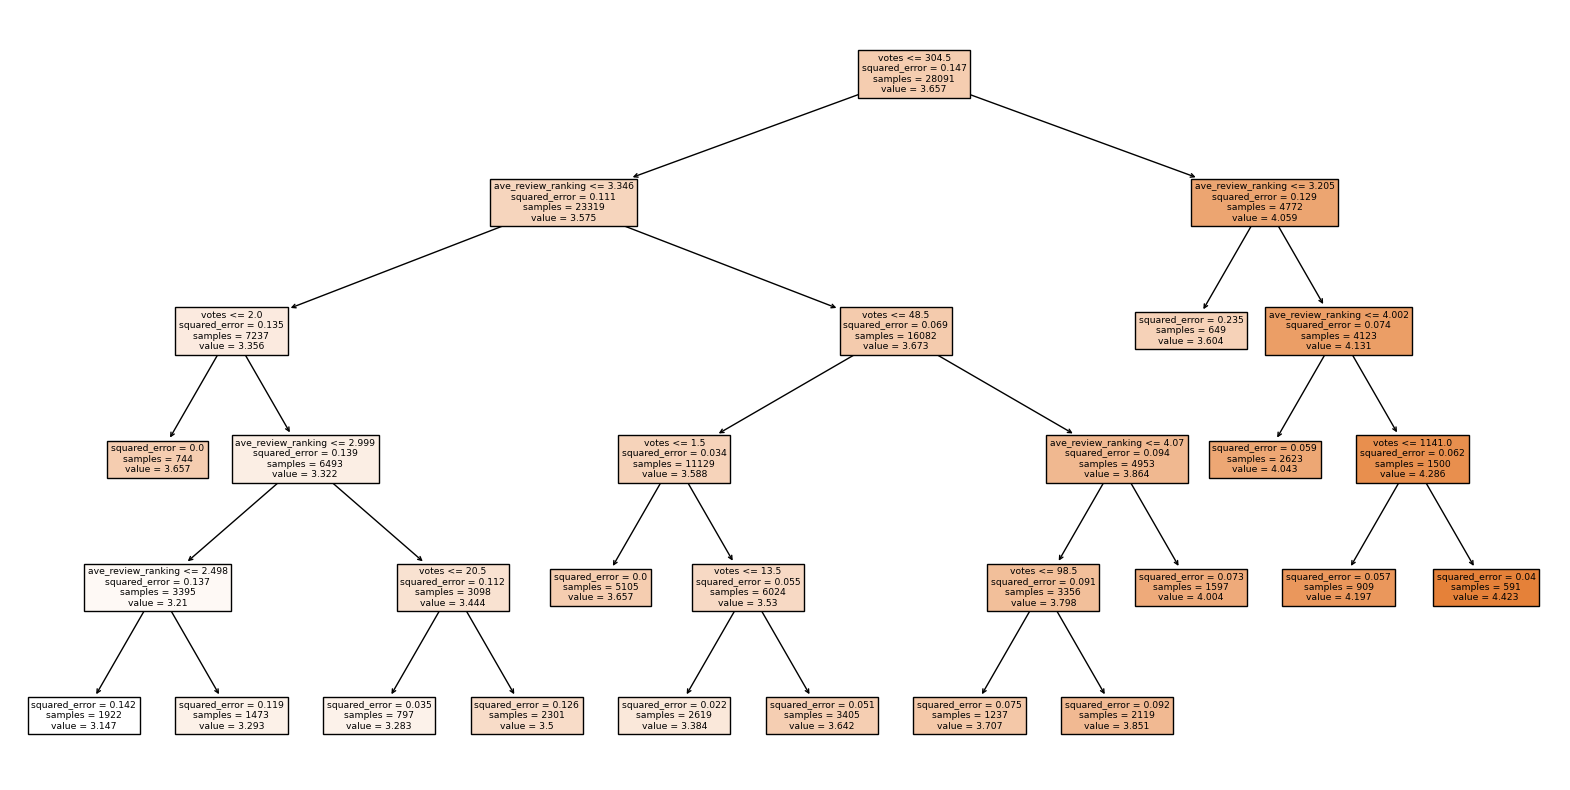

In [89]:
#Visualize the decision tree
plt.figure(figsize=(20,10))
plot_tree(regressor, filled=True, feature_names=features, class_names=['0','1'])
plt.show()

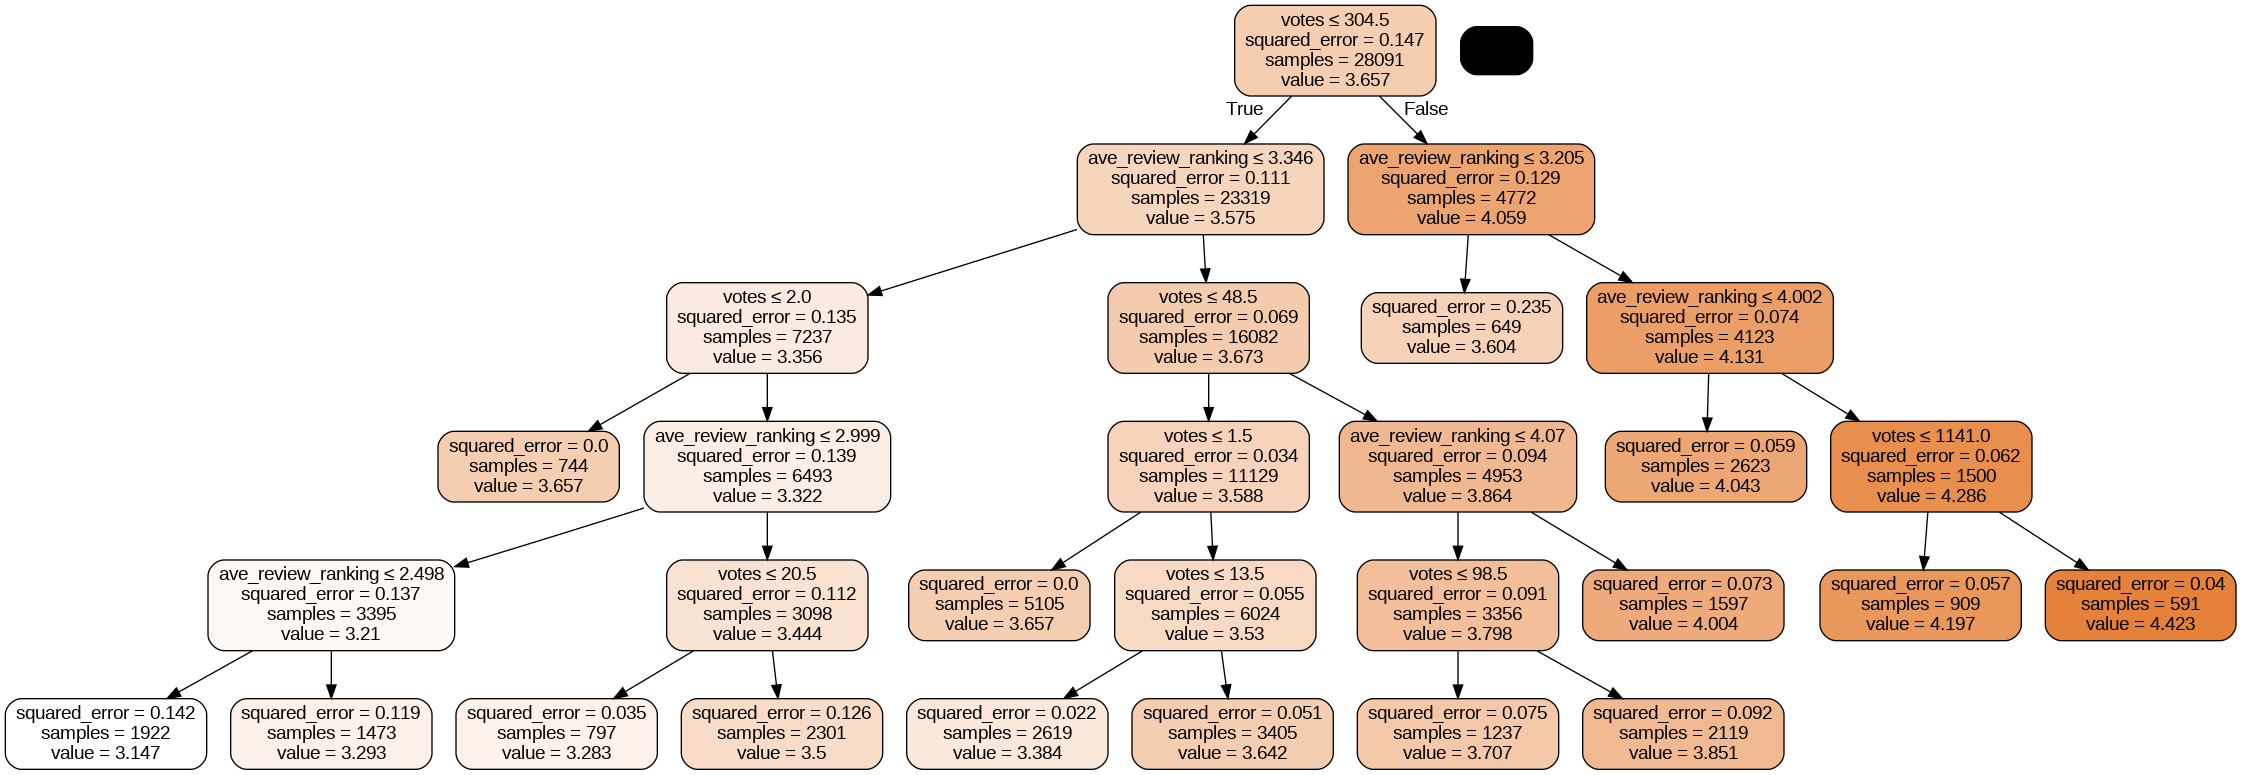

In [90]:
#Visualizing Decision Tree
import six
import sys
sys.modules['sklearn.externals.six'] = six
from sklearn.externals.six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_data = StringIO()
export_graphviz(regressor, out_file=dot_data,
filled=True, rounded=True,
special_characters=True, feature_names = features,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('HousePricePrediction.png')
Image(graph.create_png())

##**4.1 KNN Regression**

In [91]:
#Select relevant features and train and evaluate a model.
features=['ave_cost_for_two', 'votes', 'ave_review_ranking', 'book_table_N']
X=var[features]
y=var['rate']

In [92]:
#Splitting Dataset in 70% Training and 30% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2023)

In [93]:
# Normalize the features using StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [94]:
# Create a KNN regressor object
k=5
knn = KNeighborsRegressor(k)

# Code to fit the model to the SCALED training data
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [95]:
#Code to predict the Rate for the SCALED testing data
y_pred = knn.predict(X_test_scaled)

###**4.1.1 Performance Evaluation**

In [96]:
#Inspecting Actual and Predicted Rate
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
inspection.head()

,Actual,Predicted
14664,3.80,3.68
13622,3.40,3.62
22241,3.80,3.72
21139,3.80,4.00
34123,4.20,4.24


In [97]:
# Calculating Performance Metrics for the first model
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred))
r2_1 = r2_score(y_test, y_pred)
mae_1 = mean_absolute_error(y_test, y_pred)

# Printing Performance Metrics for the first model
print("Root Mean Squared Error: {:.3f}".format(rmse_1))
print("R Squared: {:.3f}".format(r2_1))
print("Absolute Squared Error: {:.3f}".format(mae_1))

Root Mean Squared Error: 0.198
R Squared: 0.737
Absolute Squared Error: 0.106


In [98]:
#Descriptive Measures for the Rate variable
var.rate.describe()

count   40130.00
mean        3.66
std         0.38
min         1.80
25%         3.50
50%         3.66
75%         3.90
max         4.90
Name: rate, dtype: float64

In [99]:
#run the below if you have problem with 'str' object is not callable - some variable is taken a built in function
import matplotlib.pyplot as plt
from importlib import reload
plt=reload(plt)

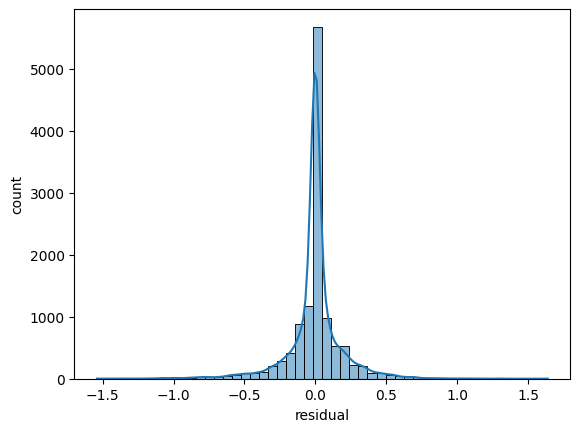

In [100]:
# Plotting Residuals, i.e. the differences between the actual and predicted values.
sns.histplot(x=y_test-y_pred, bins=50, kde=True)
plt.xlabel('residual')
plt.ylabel('count')
plt.show()

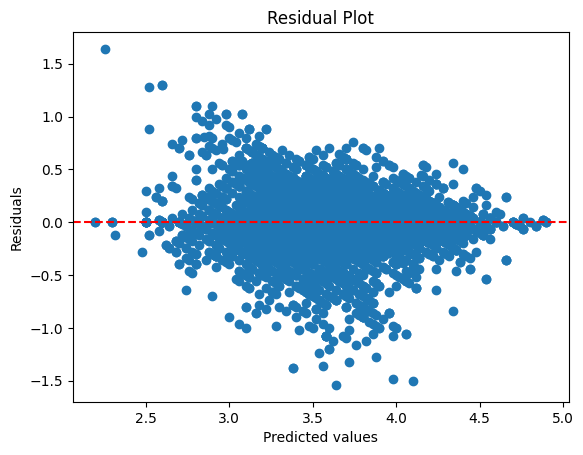

In [101]:
#Creating a Scatter Plot of residuals against predicted values
plt.scatter(y_pred, y_test-y_pred)
plt.title('Residual Plot')
plt.ylabel('Residuals')
plt.xlabel('Predicted values')
plt.axhline(y=0, color='r', linestyle='--') # Adds a horizontal line at y = 0
plt.show()

###**4.1.2 Optimising k**
Based on RMSE value

In [102]:
# Define a list of k values to test
k_values = list(range(1, 31))

# Train and evaluate KNN classifiers with different k values
best_k=5
best_rmse=5400
error_rates=[]
for k in k_values:
    knn = KNeighborsRegressor(k)
    knn.fit(X_train_scaled, y_train)
    y_pred=knn.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    error_rates.append(rmse)
    if rmse <= best_rmse:
        best_k = k
        best_rmse = rmse

# Finding the best k value with highest accuracy score
print(f"Best k Value: {best_k}")
print(f"Best RMSE: {best_rmse:.3f}")

Best k Value: 2
Best RMSE: 0.186


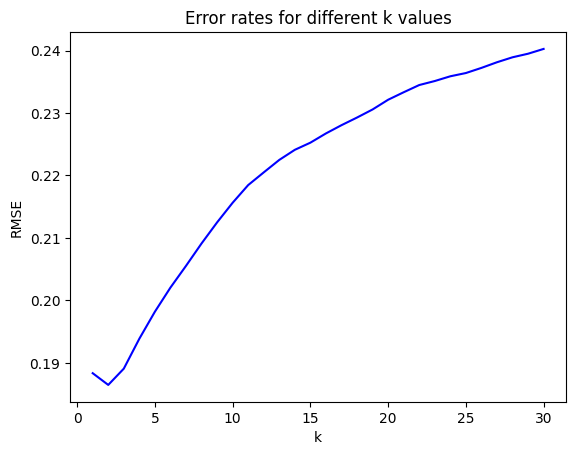

In [103]:
# Plot k values against accuracy scores
plt.ylabel('RMSE')
plt.xlabel('k')
plt.title('Error rates for different k values')
plt.plot(k_values, error_rates, color='blue')
plt.show()

### **4.1.3 Model comparision**

* Rebuild the model with the optimal k
* Evaluate the model

In [104]:
# Create a KNN regressor object
k=2
knn = KNeighborsRegressor(k)

# Fit the model to the training data
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=2)

In [105]:
# Predict the Rate for the testing data
y_pred_best = knn.predict(X_test_scaled)

In [106]:
# Calculating Performance Metrics for the SECOND model
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_2 = r2_score(y_test, y_pred_best)
mae_2 = mean_absolute_error(y_test, y_pred_best)

In [107]:
# Printing Performance metrics for the SECOND model
print("Root Mean Squared Error: {:.3f}".format(rmse_2))
print("R Squared: {:.3f}".format(r2_2))
print("Absolute Squared Error: {:.3f}".format(mae_2))

Root Mean Squared Error: 0.186
R Squared: 0.767
Absolute Squared Error: 0.082


In [108]:
#Code to print performance metrics for the FIRST model
print("Root Mean Squared Error: {:.3f}".format(rmse_1))
print("R Squared: {:.3f}".format(r2_1))
print("Absolute Squared Error: {:.3f}".format(mae_1))

Root Mean Squared Error: 0.198
R Squared: 0.737
Absolute Squared Error: 0.106


## **5.1 ANN - MLPRegressor**

In [109]:
#Selecting relevant features and train and evaluate a model.
features=['ave_cost_for_two', 'votes', 'ave_review_ranking', 'book_table_N']
X=var[features]
y=var['rate']

In [110]:
# Initialise an ANN model
ann_reg = MLPRegressor(hidden_layer_sizes=(32,16), activation='relu', solver='adam', max_iter=1000, random_state=2023)

In [111]:
#Fit it to the scaled training data
ann_reg.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=2023)

The "adam" solver, adaptive moment estimation, is a variant of stochastic gradient descent (SGD) designed for large datasets and high-dimensional parameter spaces.

In [112]:
#Using the trained model to predict on the scaled test data
y_pred_mlp= ann_reg.predict(X_test_scaled)

In [113]:
#Inspecting the Actual and Predicted Values
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred_mlp})
inspection.sample(10)

,Actual,Predicted
29566,4.00,3.69
27815,3.20,3.59
25886,3.80,4.13
4791,3.50,3.17
4935,3.30,3.24
34580,4.20,4.26
22472,4.10,3.90
15025,3.80,3.64
18459,4.30,4.01
18493,3.66,3.53


### **5.1.1 Performance Evaluation**

In [114]:
# Calculating RMSE, R-squared, and MAE
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)

# Printing the evaluation metrics
print("Scikit learn MLP RMSE: {:.3f}" .format(rmse_mlp))
print("Scikit learn MLP MAE: {:.3f}" .format(mae_mlp))
print("Scikit learn MLP R-squared: {:.3f}" .format(r2_mlp))

Scikit learn MLP RMSE: 0.263
Scikit learn MLP MAE: 0.198
Scikit learn MLP R-squared: 0.536


In [115]:
#Inspecting the Initial Rate
inspection.Actual.describe()

count   12039.00
mean        3.65
std         0.39
min         2.00
25%         3.50
50%         3.66
75%         3.90
max         4.90
Name: Actual, dtype: float64

In [116]:
#Inspecting the Predicted Rate
inspection.Predicted.describe()

count   12039.00
mean        3.63
std         0.30
min         2.83
25%         3.49
50%         3.56
75%         3.79
max         4.79
Name: Predicted, dtype: float64

<Axes: xlabel='Actual', ylabel='Predicted'>

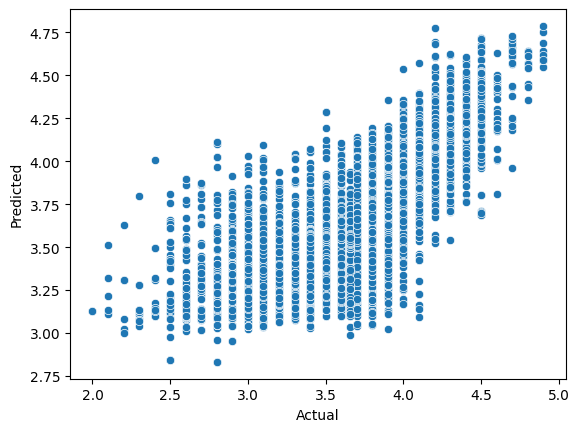

In [117]:
#Plotting a Scatterplot between Actual and Predicted Rate
sns.scatterplot(data=inspection, x='Actual', y='Predicted')

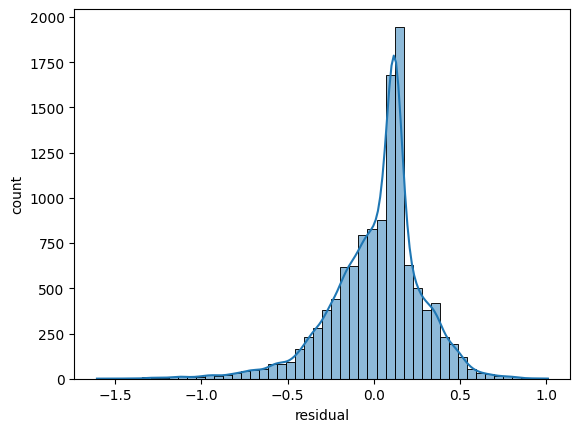

In [118]:
#Plotting Residuals, i.e. the differences between the actual and predicted values.
sns.histplot(x=y_test-y_pred_mlp, bins=50, kde=True)
plt.xlabel('residual')
plt.ylabel('count')
plt.show()

In [119]:
#occasionally plt complains about str, then run the following code
import matplotlib.pyplot as plt
from importlib import reload
plt=reload(plt)

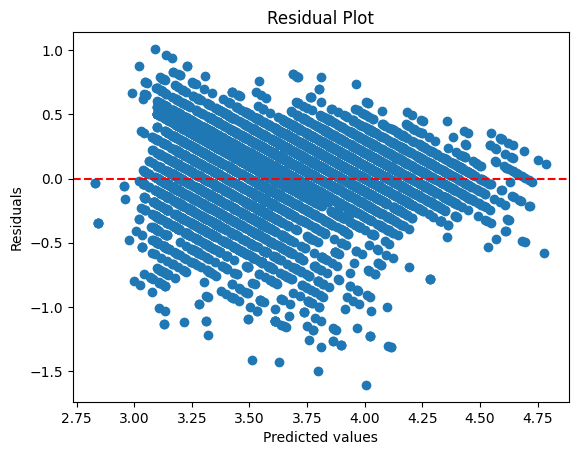

In [120]:
#Creating a Scatterplot of residuals against predicted values
plt.scatter(y_pred_mlp, y_test-y_pred_mlp)
plt.title('Residual Plot')
plt.ylabel('Residuals')
plt.xlabel('Predicted values')
plt.axhline(y=0, color='r', linestyle='--') # Adds a horizontal line at y = 0
plt.show()

###**5.1.2 Keras Model**

In [121]:
#Selecting relevant features and train and evaluate a model.
features=['ave_cost_for_two', 'votes', 'ave_review_ranking', 'book_table_N']
X=var[features]
y=var['rate']

In [122]:
#Looking at the shape of Scaled X_Train variable
X_train_scaled.shape

(28091, 4)

In [123]:
#Constructing the Keras Model
mlp_keras = Sequential()
mlp_keras.add(Dense(32, input_dim=6, activation='relu', input_shape=(X_train_scaled.shape[1],)))
mlp_keras.add(Dense(16, activation='relu'))
mlp_keras.add(Dense(1, activation='linear'))

#Compiling the Keras Model
mlp_keras.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])

#Fitting the Keras Model on the dataset
history = History()
history=mlp_keras.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=0, callbacks=[history])

The fit() function returns a History object that contains information about the training process, it stores the training loss and accuracy values for each epoch of the training process, as well as the validation loss and accuracy values if validation data is provided.

In [124]:
#Making Predictions using the model
y_pred_keras = mlp_keras.predict(X_test_scaled)

377/377 [==============================] - 1s 1ms/step


###**5.1.3 Performance Evaluation**

In [125]:
#Calculating and Printing the Performance Evaluation Metrics
rmse_keras = np.sqrt(mean_squared_error(y_test, y_pred_keras))
mae_keras = mean_absolute_error(y_test, y_pred_keras)
r2_keras = r2_score(y_test, y_pred_keras)

print('Keras MLP RMSE: {:.2f}'.format(rmse_keras))
print('Keras MLP MAE: {:.2f}'.format(mae_keras))
print('Keras MLP R-squared: {:.2f}'.format(r2_keras))

Keras MLP RMSE: 0.26
Keras MLP MAE: 0.19
Keras MLP R-squared: 0.55


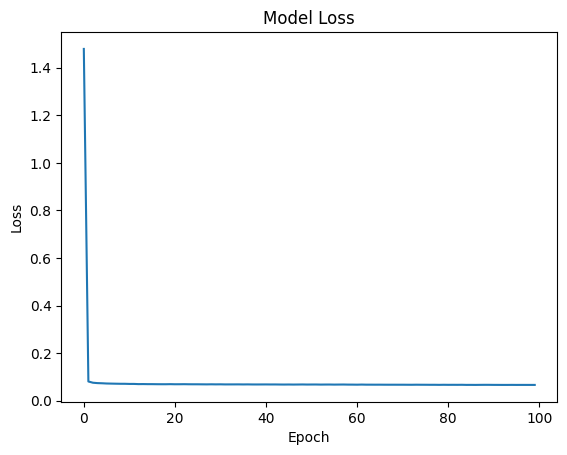

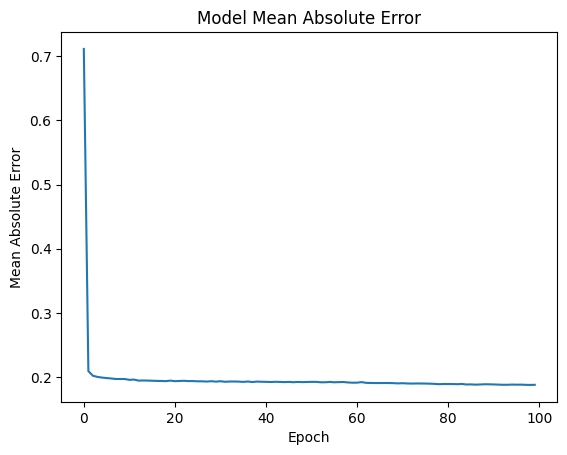

In [126]:
#Plotting the Loss and Accuracy over Epochs
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

plt.plot(history.history['mean_absolute_error'])
plt.title('Model Mean Absolute Error')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.show()

In [127]:
#Calculating the Residuals
residuals_keras = y_test - y_pred_keras.squeeze()

In [128]:
#Occasionally plt complains about str, then run the following code
import matplotlib.pyplot as plt
from importlib import reload
plt=reload(plt)

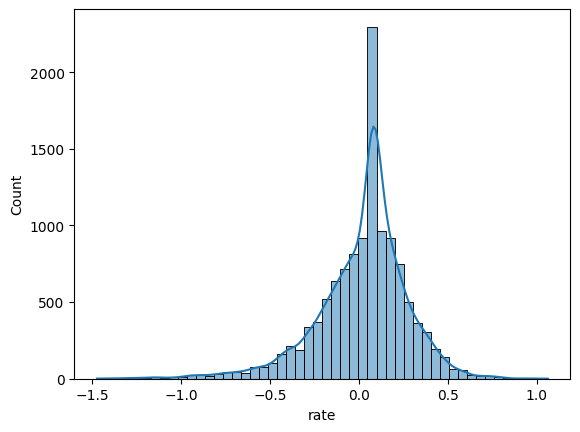

In [129]:
#Plot residuals, i.e. the differences between the actual and predicted values.
sns.histplot(residuals_keras, bins=50, kde=True)
plt.xlabel='error'
plt.ylabels='count'
plt.show()

In [130]:
#run the below if you have problem with 'str' object is not callable - some variable is taken a built in function
import matplotlib.pyplot as plt
from importlib import reload
plt=reload(plt)

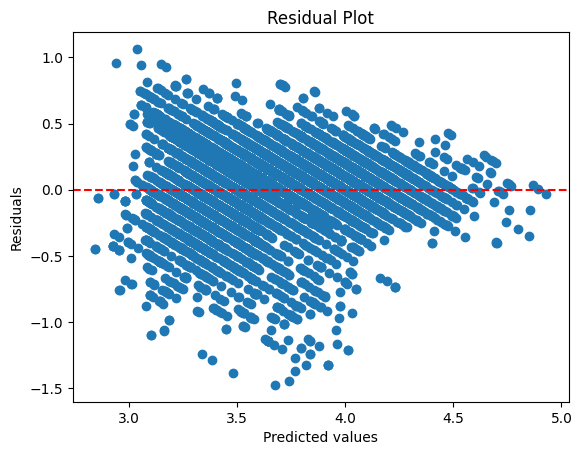

In [131]:
#Create a scatter plot of Residuals against Predicted values
plt.scatter(y_pred_keras, residuals_keras)
plt.title('Residual Plot')
plt.ylabel('Residuals')
plt.xlabel('Predicted values')
plt.axhline(y=0, color='r', linestyle='--') # Adds a horizontal line at y = 0
plt.show()

### **5.1.4 Model Comparision**

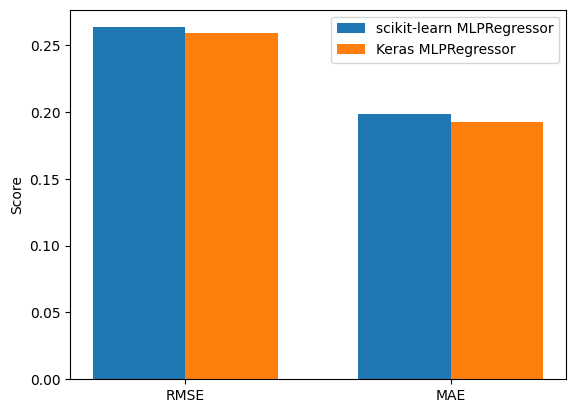

In [132]:
# Creating a Bar Plot for the Evaluation Metrics
labels = ['RMSE', 'MAE']
mlp_scores = [rmse_mlp, mae_mlp]
keras_scores = [rmse_keras, mae_keras]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, mlp_scores, width, label='scikit-learn MLPRegressor')
rects2 = ax.bar(x + width/2, keras_scores, width, label='Keras MLPRegressor')

ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()

In [133]:
# Calculating the regression line for MLP
slope_mlp, intercept_mlp = np.polyfit(y_test, y_pred_mlp, 1)
regression_line_mlp = slope_mlp * y_test + intercept_mlp

In [134]:
# Calculating the regression line for Keras
slope_keras, intercept_keras = np.polyfit(y_test, y_pred_keras, 1)
regression_line_keras = slope_keras * y_test + intercept_keras

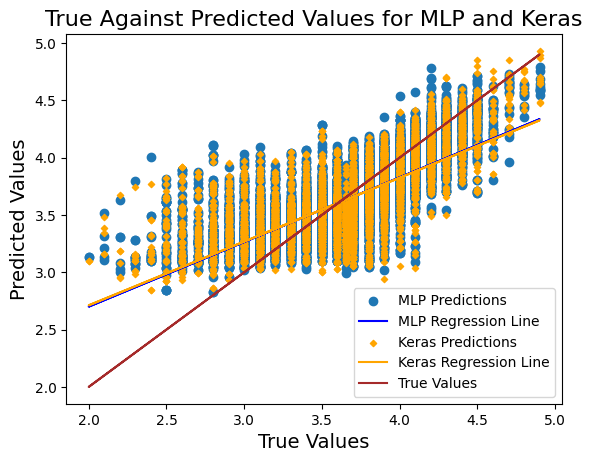

In [135]:
# Creating a scatter plot of true against predicted values for MLP and Keras
plt.scatter(y_test, y_pred_mlp, label='MLP Predictions')
plt.plot(y_test, regression_line_mlp, color='blue', label='MLP Regression Line')
plt.scatter(y_test, y_pred_keras, marker='D', s=10, color='orange', label='Keras Predictions')
plt.plot(y_test, regression_line_keras, color='orange', label='Keras Regression Line')

# Add black dots along the diagonal to mark where true values should lie
plt.plot(y_test, y_test, color='brown', label='True Values')

plt.title('True Against Predicted Values for MLP and Keras', fontsize=16)
plt.ylabel('Predicted Values', fontsize=14)
plt.xlabel('True Values', fontsize=14)
plt.legend(loc="lower right", fontsize=10)  # Increase font size for the legend
plt.show()

##**6.1 Ensemble Learning for Regression**

In [136]:
#Selecting relevant features and train and evaluate a model.
features=['ave_cost_for_two', 'votes', 'ave_review_ranking', 'book_table_N']
X=var[features]
y=var['rate']

In [137]:
#Features to scale
features_to_scale = ['ave_cost_for_two', 'ave_review_ranking','votes', 'rate']

#Features to keep
features_to_keep = ['book_table_N']

In [138]:
# Scale the features using Min-Max Scaling
scaler = MinMaxScaler(clip=True)

In [139]:
# Fit and transform the features to scale
X_scaled_values = scaler.fit_transform(X)

# Create DataFrames from the scaled values
X_scaled = pd.DataFrame(X_scaled_values, columns=features_to_scale)

# Concatenate the unscaled features back into the scaled DataFrames
X_scaled = pd.concat([X_scaled, X[features_to_keep].reset_index(drop=True)], axis=1)

### **6.1.1 RandomForestRegressor**

In [140]:
# Creating the Random Forest Regressor Ensemble Learner Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=2023)

# Train the model on the training data
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the testing data
y_pred_rf = rf_model.predict(X_test_scaled)

# Calculate the mean squared error of the model's predictions
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Calculate the R2 score
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Root Mean Squared Error in: {np.sqrt(mse_rf):.3f}")
print(f"R2: {r2_rf:.4f}")

Root Mean Squared Error in: 0.153
R2: 0.8425


### **6.1.2 Ada Boost Regressor**

In [141]:
# Creating the Ada Boost Regressor Ensemble Learner Model
ab_model = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=2023)

# Train the model on the training data
ab_model.fit(X_train_scaled, y_train)

#Code to make predictions on the testing data
y_pred_ab = ab_model.predict(X_test_scaled)

#Code to calculate the mean squared error of the model's predictions
mse_ab = mean_squared_error(y_test, y_pred_ab)

#Code to calculate the R2 score
r2_ab = r2_score(y_test, y_pred_ab)

print(f"Root Mean Squared Error in: {np.sqrt(mse_ab):.3f}")
print(f"R2: {r2_ab:.4f}")

Root Mean Squared Error in: 0.289
R2: 0.4390


### **6.1.3 Gradient Boosting Regressor**

In [142]:
# Creating the Gradient Boosting Regressor ensemble learner model
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=2023)

# Train the model on the training data
gbr_model.fit(X_train_scaled, y_train)

# Make predictions on the testing data
y_pred_gbr = gbr_model.predict(X_test_scaled)

# Calculate the mean squared error of the model's predictions
mse_gbr = mean_squared_error(y_test, y_pred_gbr)

# Calculate the R2 score
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Root Mean Squared Error in: {np.sqrt(mse_gbr):.3f}")
print(f"R2: {r2_gbr:.4f}")

Root Mean Squared Error in: 0.234
R2: 0.6333


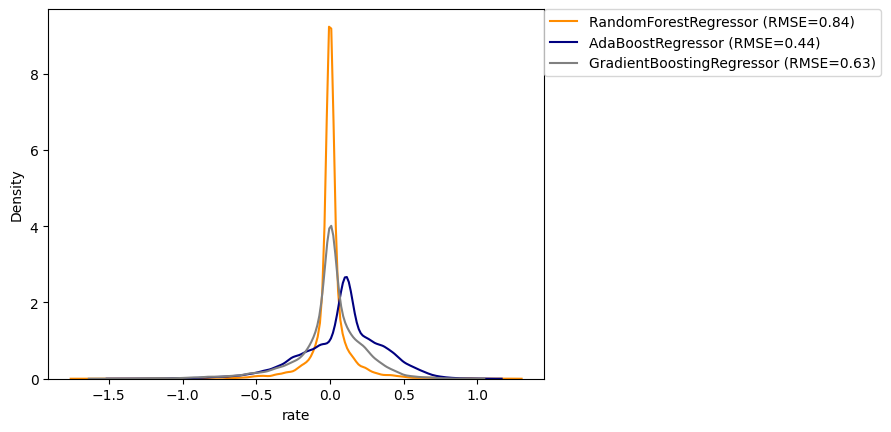

In [143]:
#Plotting Kernel Density Estimate Plots for RandomForestRegressor, AdaBoostRegressor and GradientBoosting Regressor
fig, ax = plt.subplots()

sns.kdeplot(x=y_test-y_pred_rf, color='darkorange', label=f'RandomForestRegressor (RMSE={r2_rf:.2f})', ax=ax)
sns.kdeplot(x=y_test-y_pred_ab, color='navy', label=f'AdaBoostRegressor (RMSE={r2_ab:.2f})' , ax=ax)
sns.kdeplot(x=y_test-y_pred_gbr, color='gray', label=f'GradientBoostingRegressor (RMSE={r2_gbr:.2f})' , ax=ax)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), borderaxespad=0.)
plt.show()

###**6.1.4 Stacking**

In [144]:
#Defining the Estimators for Stacking
estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=2023)),
    ('ab', AdaBoostRegressor(n_estimators=100, random_state=2023)),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=2023))
]

In [145]:
# Defining the meta-classifier
meta_classifier = LinearRegression()

# Creating the Stacking Regressor model
stacking_regressor = StackingRegressor(estimators=estimators, final_estimator=meta_classifier)

In [146]:
# Fitting the stacking model on the scaled training data
stacking_regressor.fit(X_train_scaled, y_train)

StackingRegressor(estimators=[('rf', RandomForestRegressor(random_state=2023)),
                              ('ab',
                               AdaBoostRegressor(n_estimators=100,
                                                 random_state=2023)),
                              ('gb',
                               GradientBoostingRegressor(random_state=2023))],
                  final_estimator=LinearRegression())

In [147]:
#Code to evaluate on the scaled test data
y_pred_stackedmodel = stacking_regressor.predict(X_test_scaled)

In [148]:
#Importing the necessary performance evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [149]:
#Calculating the Mean Squared Error Value
mse = mean_squared_error(y_test, y_pred_stackedmodel)

#Calculating the Root Mean Squared Error Value
rmse = np.sqrt(mse)

#Calculating the Mean Absolute Error Value
mae = mean_absolute_error(y_test, y_pred_stackedmodel)

# Calculating the R-Squared Score
r2 = r2_score(y_test, y_pred_stackedmodel)

# Printing the results
print(f"Root Mean Squared Error: {rmse:.3f}")
print(f"Mean Absolute Error: {mae:.3f}")
print(f"R2 Score: {r2:.3f}")

Root Mean Squared Error: 0.153
Mean Absolute Error: 0.073
R2 Score: 0.843


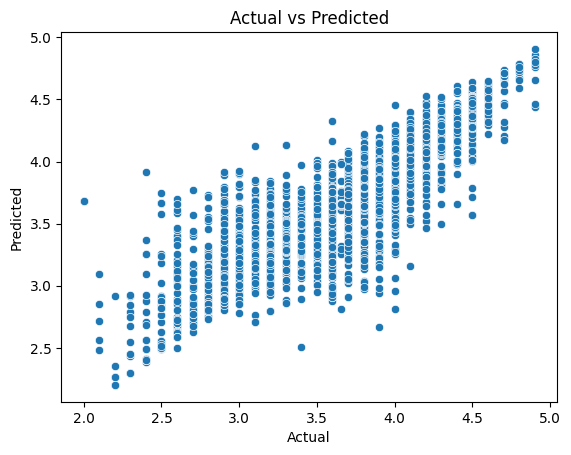

In [150]:
#Plotting Scatterplot between Actual and Predicted Rate
sns.scatterplot(data=inspection, x=y_test, y=y_pred_stackedmodel)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [151]:
#run the below if you have problem with 'str' object is not callable - some variable is taken a built in function
import matplotlib.pyplot as plt
from importlib import reload
plt=reload(plt)

In [152]:
residuals_stackedmodel = y_test - y_pred_stackedmodel

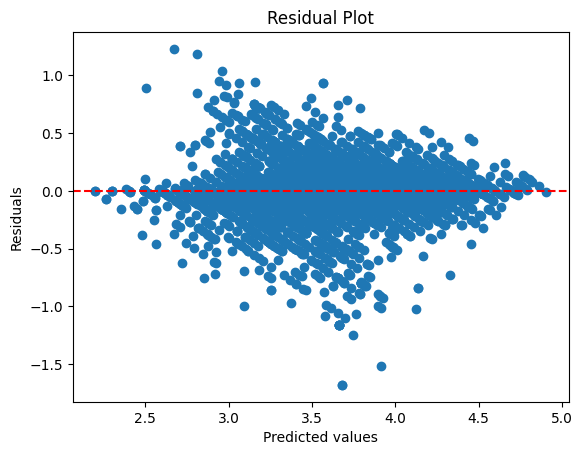

In [153]:
# Creating a Scatterplot of residuals against predicted values
plt.scatter(y_pred_stackedmodel, residuals_stackedmodel)
plt.title('Residual Plot')
plt.ylabel('Residuals')
plt.xlabel('Predicted values')
plt.axhline(y=0, color='r', linestyle='--') # Adds a horizontal line at y = 0
plt.show()

## **7.1 K-Means Clustering**

### **7.1.1 Model Building**

**Feature selection and target specification**

In [154]:
#Selecting relevant features and train and evaluate a model.
features=['ave_cost_for_two', 'votes', 'ave_review_ranking', 'book_table_N', 'rate']
X=var[features]

**Spliting and scaling data**

In [155]:
#Features to scale
features_to_scale = ['ave_cost_for_two', 'ave_review_ranking','votes', 'rate', 'book_table_N']

#Features to keep
features_to_keep = []

In [156]:
# Scale the features using Min-Max Scaling
scaler = MinMaxScaler()

In [157]:
# Fit and transform the features to scale
X_scaled_values = scaler.fit_transform(X)

# Create DataFrames from the scaled values
X_scaled = pd.DataFrame(X_scaled_values, columns=features_to_scale)

# Concatenate the unscaled features back into the scaled DataFrames
X_scaled = pd.concat([X_scaled, X[features_to_keep].reset_index(drop=True)], axis=1)

In [158]:
# Fit K-means clustering model with an initially selected number of clusters
k=2
kmeans = KMeans(n_clusters=k, n_init='auto', max_iter=300, random_state=2023)

#Write code to fit kmeans with X_scaled
kmeans.fit(X_scaled)

KMeans(n_clusters=2, n_init='auto', random_state=2023)

In [159]:
# Evaluate the model using Within-Cluster Sum of Squares (WCSS)
wcss = kmeans.inertia_
print("Within-Cluster Sum of Squares (WCSS):", '%.3f' % wcss)

#Computing the Davies-Bouldin index
dbs = davies_bouldin_score(X_scaled, kmeans.labels_)
print("Davies Bouldin index:", '%.3f' % dbs)

#Computing the Silhouette score for the clustering model
silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)

print('Silhouette score:', '%.3f' % silhouette_avg)

Within-Cluster Sum of Squares (WCSS): 5489.225
Davies Bouldin index: 1.332
Silhouette score: 0.244


### **7.1.2 Performance Evaluation and Optimisation**
* Within-Cluster Sum of Squares
* Silhouette score
* k optimisation


**Let's create a graph to observe both metrics**

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

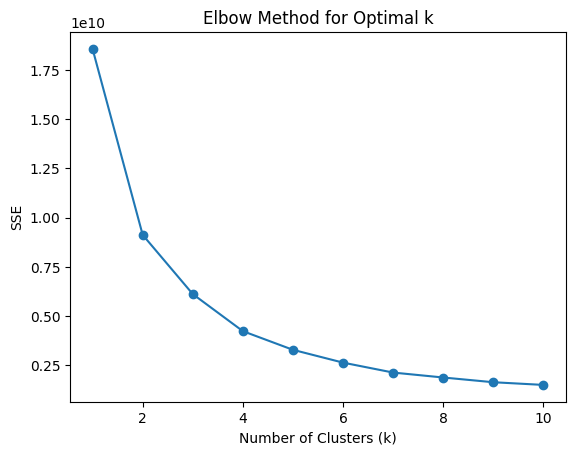

In [160]:
#Assuming X is your data
sse_scores = []

#Choose a range of k values to explore
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse_scores.append(kmeans.inertia_)

#Plotting SSE vs. k
plt.plot(k_range, sse_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal k')
plt.show()

In [161]:
#Determining optimal number of clusters using the SSE metric
sse_scores = []
best_k=2
best_sse_score=4622.613
for i in range(2, 41):
  kmeans = KMeans(n_clusters=i, n_init=2)
  kmeans.fit(X_scaled)
  sse_score_i=kmeans.inertia_
  sse_scores.append(sse_score_i)
  if best_sse_score > sse_score_i:
    best_k = i
    best_sse_score = sse_score_i

print('Best k: ', best_k)
print('Best within cluster sum of squarred error score: ', '%.3f' %best_sse_score)

Best k:  40
Best within cluster sum of squarred error score:  298.222


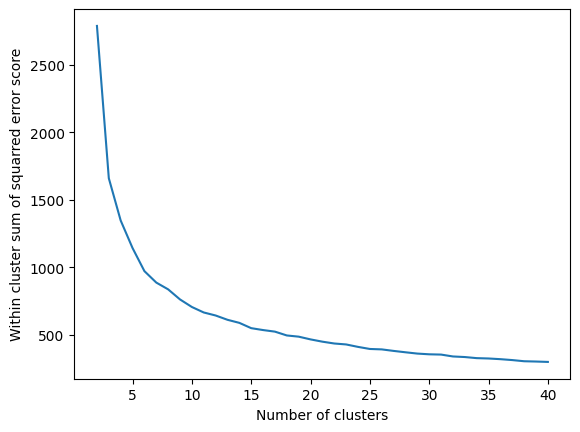

In [162]:
#Plotting the Silhouette Scores to determine optimal number of clusters
plt.plot(range(2,41), sse_scores)
plt.xlabel("Number of clusters")
plt.ylabel("Within cluster sum of squarred error score")
plt.show()

In [163]:
#Estimating optimal k using Davies Bouldin Scores
dbs_scores = []
best_k=4
best_dbs_score=1
for k in range(2, 41):
  kmeans = KMeans(n_clusters=k, n_init='auto', max_iter=300, random_state=2023)
  kmeans.fit(X_scaled)
  dbs_score_k=davies_bouldin_score(X_scaled, kmeans.labels_)
  dbs_scores.append(dbs_score_k)
  if best_dbs_score > dbs_score_k:
    best_k = k
    best_dbs_score = dbs_score_k

print('Best k: ', best_k)
print('Best Davies Bouldin index: ', '%.3f' %best_dbs_score)

Best k:  3
Best Davies Bouldin index:  0.754


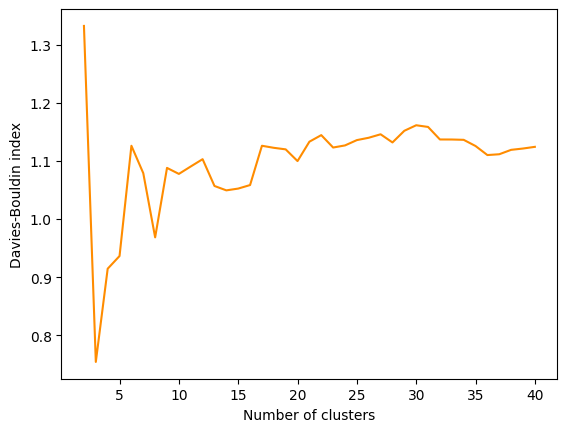

In [164]:
#Plotting the Davies-Bouldin indices to determine optimal number of clusters
plt.plot(range(2,41), dbs_scores, color='darkorange', label='Davies Bouldin index')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin index')
plt.show()

In [165]:
# Determining optimal number of clusters using silhouette score
sil_scores = []
best_k=2
best_sil_score=0
for i in range(2, 41):
  kmeans = KMeans(n_clusters=i, n_init=2)
  kmeans.fit(X_scaled)
  sil_score_i=silhouette_score(X_scaled, kmeans.labels_)
  sil_scores.append(sil_score_i)
  if best_sil_score < sil_score_i:
    best_k = i
    best_sil_score = sil_score_i

print('Best k: ', best_k)
print('Best silhouette score: ', '%.3f' %best_sil_score)

Best k:  2
Best silhouette score:  0.712


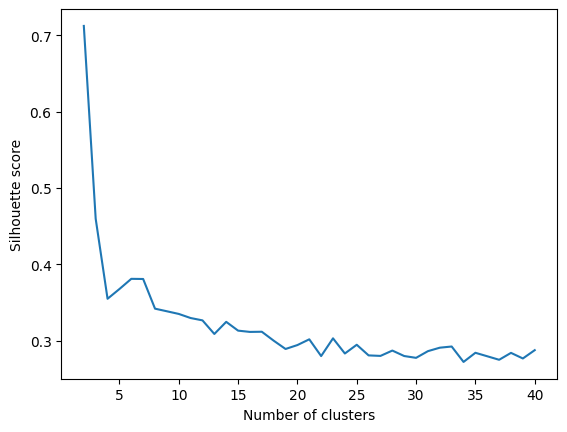

In [166]:
# Plotting the Silhouette Scores to determine optimal number of clusters
plt.plot(range(2,41), sil_scores)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

### **7.1.3 Model Selection**

In [167]:
#Setting the number of clusters
n_clusters = 3

#Fit K-means clustering model
kmeans = KMeans(n_clusters=n_clusters, n_init='auto', random_state=2023)
cluster_labels = kmeans.fit_predict(X_scaled)

# Write code to add cluster labels to original dataset
var['Cluster'] = kmeans.labels_

In [168]:
# Evaluate the model using within-cluster sum of squares (WCSS)
wcss = kmeans.inertia_
print("Within-Cluster Sum of Squares (WCSS):", '%.3f' % wcss)

# Write code to compute the Davies-Bouldin index
dbs = davies_bouldin_score(X_scaled, kmeans.labels_)
print("Davies Bouldin index:", '%.3f' % dbs)

# Write code to compute the Silhouette score for the clustering model
silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)

print('Silhouette score:', '%.3f' % silhouette_avg)

Within-Cluster Sum of Squares (WCSS): 1658.554
Davies Bouldin index: 0.754
Silhouette score: 0.460


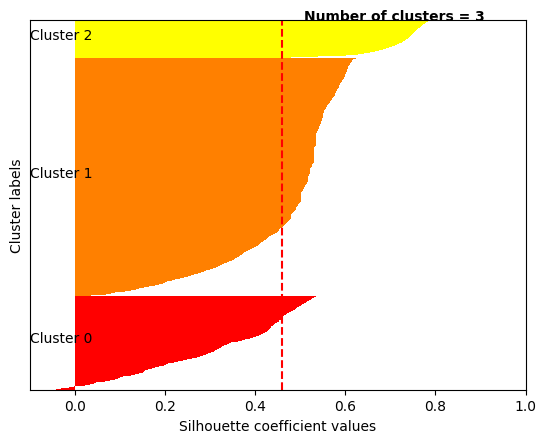

In [169]:
#Compute silhouette scores
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

# Define the colormap, options include: autumn, Spectral, viridis, plasma, cool, jet
cmap = cm.autumn

# Create a list of evenly spaced values in the range [0, 1]
values = np.linspace(0, 1, n_clusters)

# Plot silhouette diagram
fig, ax = plt.subplots()
y_lower, y_upper = 0, 0
for i in range(n_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper += size_cluster_i
    color = cmap(values[i])
    ax.barh(range(y_lower, y_upper), ith_cluster_silhouette_values, height=1.0,
            edgecolor='none', color=color)
    ax.text(-0.1, (y_lower + y_upper) / 2, 'Cluster ' + str(i), color='black', fontsize=10)
    y_lower += size_cluster_i

ax.axvline(x=silhouette_avg, color="red", linestyle="--")
ax.set_xlabel("Silhouette coefficient values")
ax.set_ylabel("Cluster labels")
ax.set_yticks([])
ax.set_xlim([-0.1, 1])
ax.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

ax.text(silhouette_avg + 0.05, len(X_scaled) + 5, "Number of clusters = %d" % n_clusters, fontsize=10, fontweight='bold')

plt.show()

### **7.1.4 Post-analysis for Cluster Profiling**

Now that we have Clustered assigned to each data point, we can examine the cluster desriptive stats and visualisation

*Examine the Cluster size*

In [170]:
var

,rest_type,listed_in_type,online_order,book_table,ave_cost_for_two,votes,ave_review_ranking,rate,online_order_N,book_table_N,rest_type_N,Cluster
0,Cafe,Cafes,No,No,700.00,13,4.75,3.60,0,0,3,1
1,Quick Bites,Dine-out,Yes,No,400.00,28,4.50,3.80,1,0,1,1
2,Quick Bites,Delivery,Yes,No,200.00,18,4.00,3.90,1,0,1,1
3,Casual Dining,Delivery,Yes,Yes,1200.00,550,4.80,4.30,1,1,2,2
4,Cafe,Dine-out,Yes,No,250.00,67,3.00,3.70,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
40125,"Takeaway, Delivery",Delivery,No,No,400.00,25,2.00,2.90,0,0,5,0
40126,"Takeaway, Delivery",Delivery,Yes,No,500.00,23,3.45,3.60,1,0,5,1
40127,Quick Bites,Delivery,No,No,300.00,23,3.45,3.10,0,0,1,1
40128,Quick Bites,Delivery,Yes,No,500.00,162,3.50,4.00,1,0,1,1


In [171]:
#Number of Restaurants in each Clusters
cluster_count=var.Cluster.value_counts()
cluster_count

1    25823
0    10213
2     4094
Name: Cluster, dtype: int64

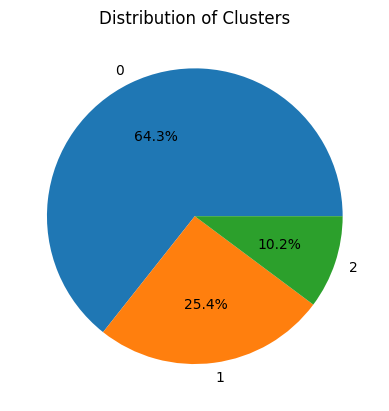

In [172]:
#Generating a pie chart with the distribution of churned cases, along with percentage labels.

# Sort the index to ensure the clusters are in order
sorted_cluster_count = cluster_count.sort_index()
colours = sns.color_palette("tab10", n_colors=len(cluster_count))

plt.pie(cluster_count, labels=sorted_cluster_count.index, autopct='%1.1f%%', colors=colours)
plt.title('Distribution of Clusters')
plt.show()

*Examine Cluster vs each of other variables*

In [173]:
#Calculating Mutual Information Score
mi_scores = {}

cats = ['book_table', 'online_order', 'rest_type', 'listed_in_type']

# Loop through each categorical feature and calculate MI score
for cat in cats:
    mi_scores[cat] = mutual_info_score(var[cat], var['Cluster'])

# Sort features by their MI scores
sorted_scores = sorted(mi_scores.items(), key=lambda x: x[1], reverse=True)

# Display the scores
for feature, score in sorted_scores:
    print(f"{feature}: {score:.3f}")

book_table: 0.329
rest_type: 0.114
listed_in_type: 0.029
online_order: 0.010


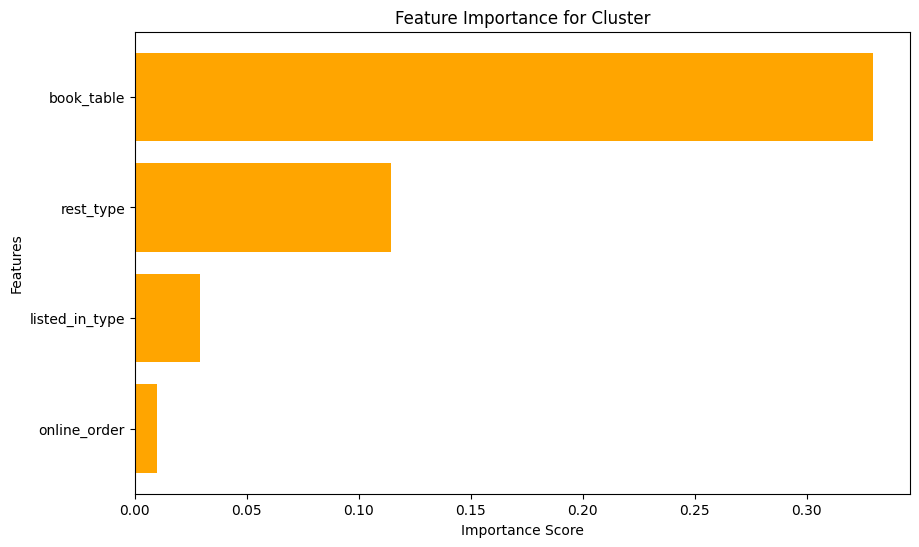

In [174]:
#Plotting Bar Plots for Feature Importance
features, scores = zip(*sorted_scores)
plt.figure(figsize=(10, 6))
plt.barh(features, scores, color='orange')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance for Cluster')
plt.gca().invert_yaxis()
plt.show()

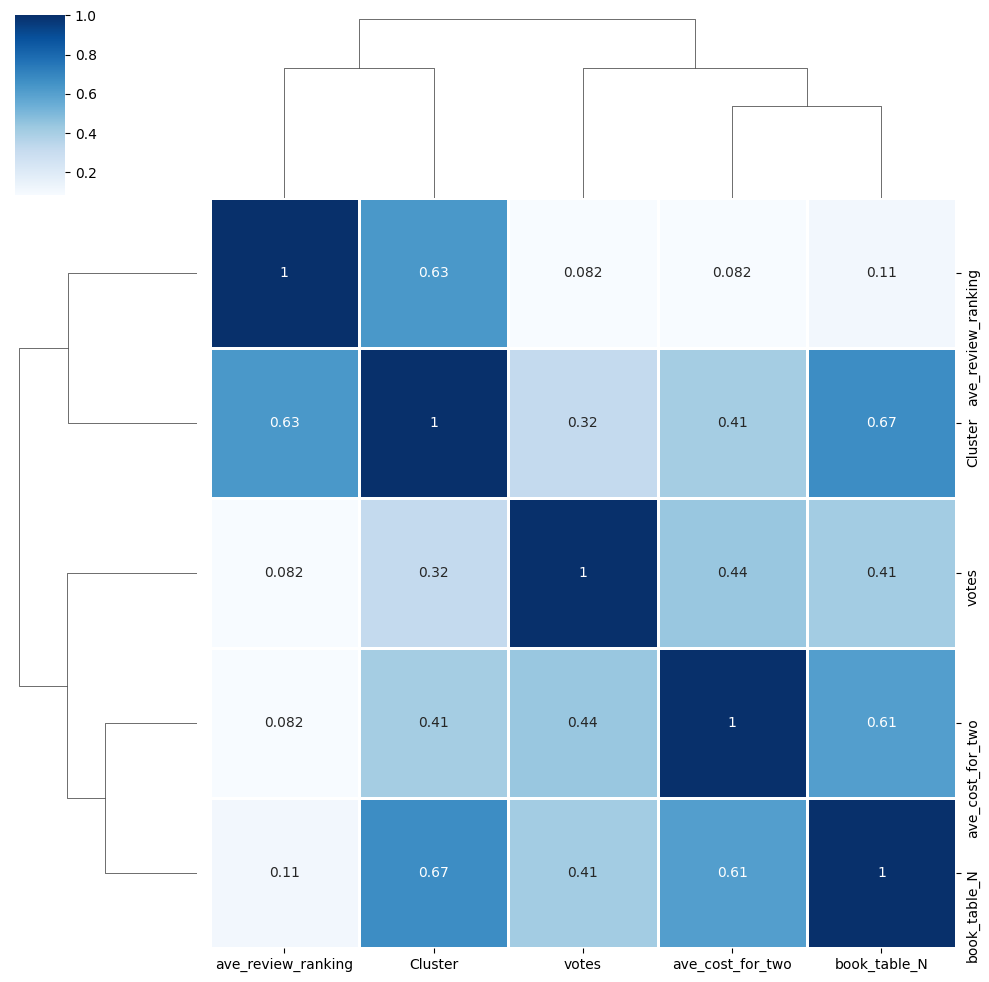

In [175]:
#Visualising Clustermap
sns.clustermap(data=var[['ave_cost_for_two','votes', 'ave_review_ranking','book_table_N', 'Cluster']].corr(), cmap="Blues", linewidths=.9, annot=True)

Cluster  book_table
0        No            10213
1        No            25823
2        Yes            4094
Name: book_table, dtype: int64




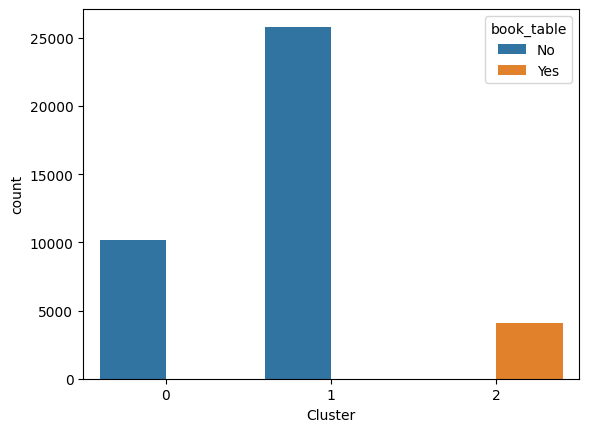

In [176]:
#Plotting Bar Plots between Cluster and Book Table
print(var.groupby('Cluster')['book_table'].value_counts())
print('\n')
sns.countplot(hue=var['book_table'], x=var['Cluster'], palette='tab10')
plt.show()

Cluster  online_order
0        Yes              7138
         No               3075
1        Yes             14500
         No              11323
2        Yes              2921
         No               1173
Name: online_order, dtype: int64




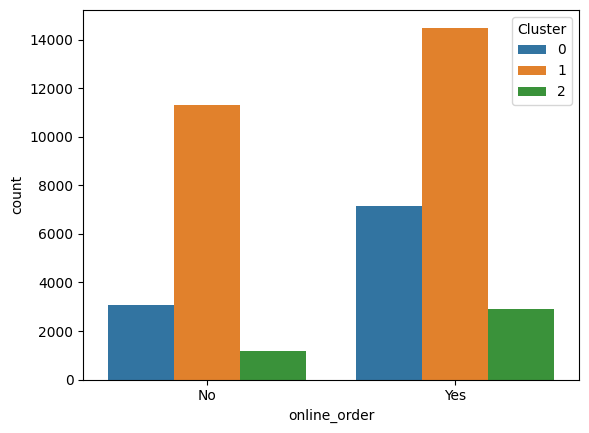

In [177]:
#Plotting Bar Plots between Cluster and Online Order
print(var.groupby('Cluster')['online_order'].value_counts())
print('\n')
sns.countplot(hue=var['Cluster'], x=var['online_order'], palette='tab10')
plt.show()

Cluster  rest_type         
0        Quick Bites            5476
         Casual Dining          2400
         Delivery                752
         Takeaway, Delivery      676
         Cafe                    631
         Bakery                  191
         Casual Dining, Bar       87
1        Quick Bites           13557
         Casual Dining          5313
         Cafe                   2546
         Delivery               1852
         Takeaway, Delivery     1357
         Bakery                  950
         Casual Dining, Bar      248
2        Casual Dining          2617
         Casual Dining, Bar      819
         Cafe                    555
         Quick Bites              99
         Takeaway, Delivery        4
Name: rest_type, dtype: int64




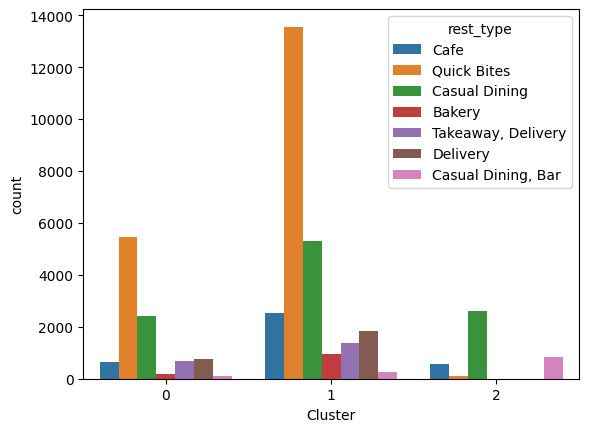

In [178]:
#Plotting Bar Plots between Cluster and Restaurant Type
print(var.groupby('Cluster')['rest_type'].value_counts())
print('\n')
sns.countplot(hue=var['rest_type'], x=var['Cluster'], palette='tab10')
plt.show()

Cluster  listed_in_type    
0        Delivery               6048
         Dine-out               3652
         Cafes                   202
         Desserts                187
         Buffet                   96
         Pubs and bars            16
         Drinks & nightlife       12
1        Delivery              13845
         Dine-out               9785
         Desserts               1003
         Cafes                   916
         Buffet                  171
         Pubs and bars            62
         Drinks & nightlife       41
2        Dine-out               1572
         Delivery               1553
         Buffet                  425
         Cafes                   174
         Pubs and bars           148
         Drinks & nightlife      129
         Desserts                 93
Name: listed_in_type, dtype: int64




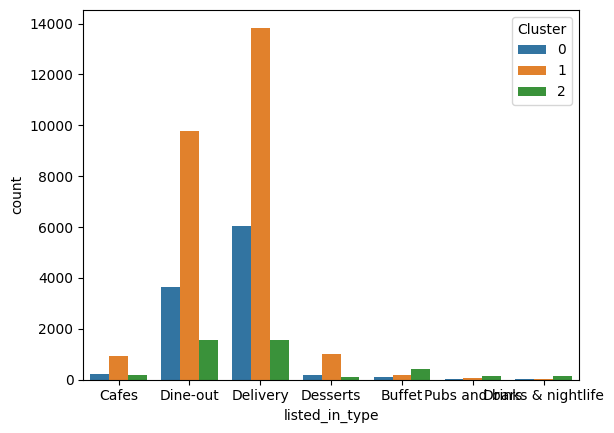

<Figure size 2000x1000 with 0 Axes>

In [179]:
#Plotting Bar Plots between Cluster and Listed in Type
print(var.groupby('Cluster')['listed_in_type'].value_counts())
print('\n')
sns.countplot(hue=var['Cluster'], x=var['listed_in_type'],palette='tab10')
plt.figure(figsize=(20,10))
plt.show()

ave_cost_for_two :

           count    mean    std    min    25%     50%     75%     max
Cluster                                                              
0       10213.00  440.98 210.32  40.00 300.00  400.00  550.00 2000.00
1       25823.00  439.52 246.18  40.00 300.00  400.00  550.00 2200.00
2        4094.00 1088.12 393.28 200.00 800.00 1000.00 1400.00 2500.00




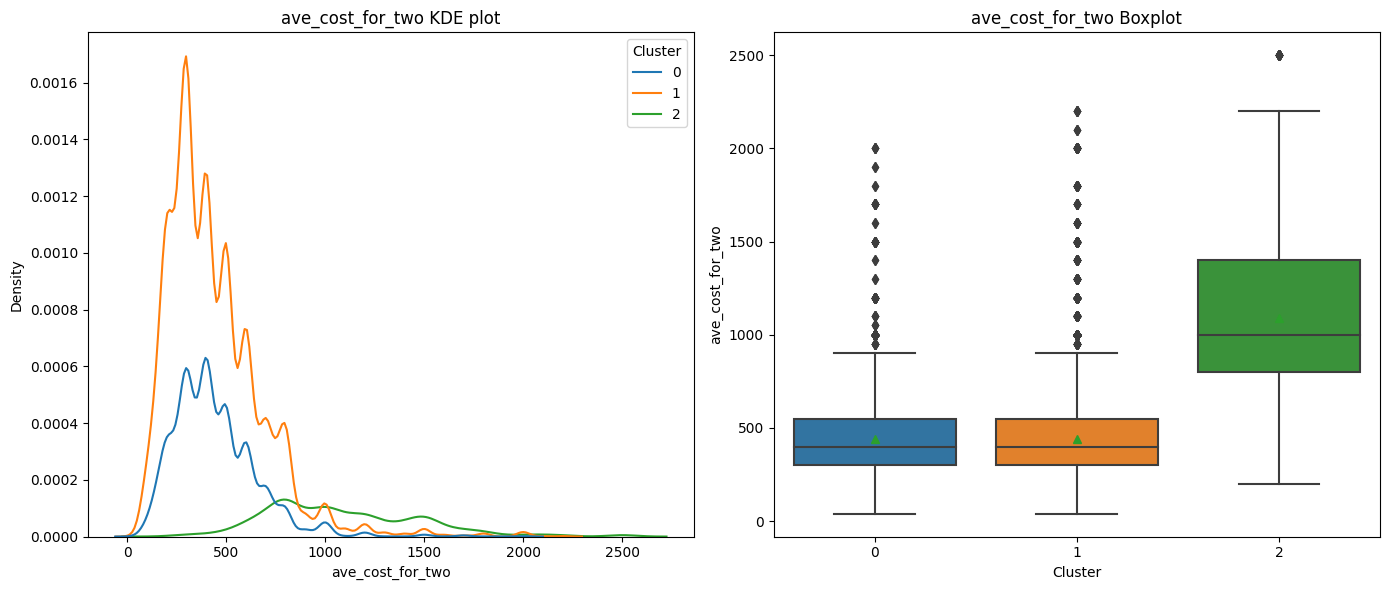

ave_review_ranking :

           count  mean  std  min  25%  50%  75%  max
Cluster                                             
0       10213.00  2.51 0.69 1.00 2.00 2.78 3.00 3.60
1       25823.00  4.00 0.48 3.00 3.73 3.83 4.25 5.00
2        4094.00  3.88 0.52 1.00 3.62 3.97 4.20 5.00




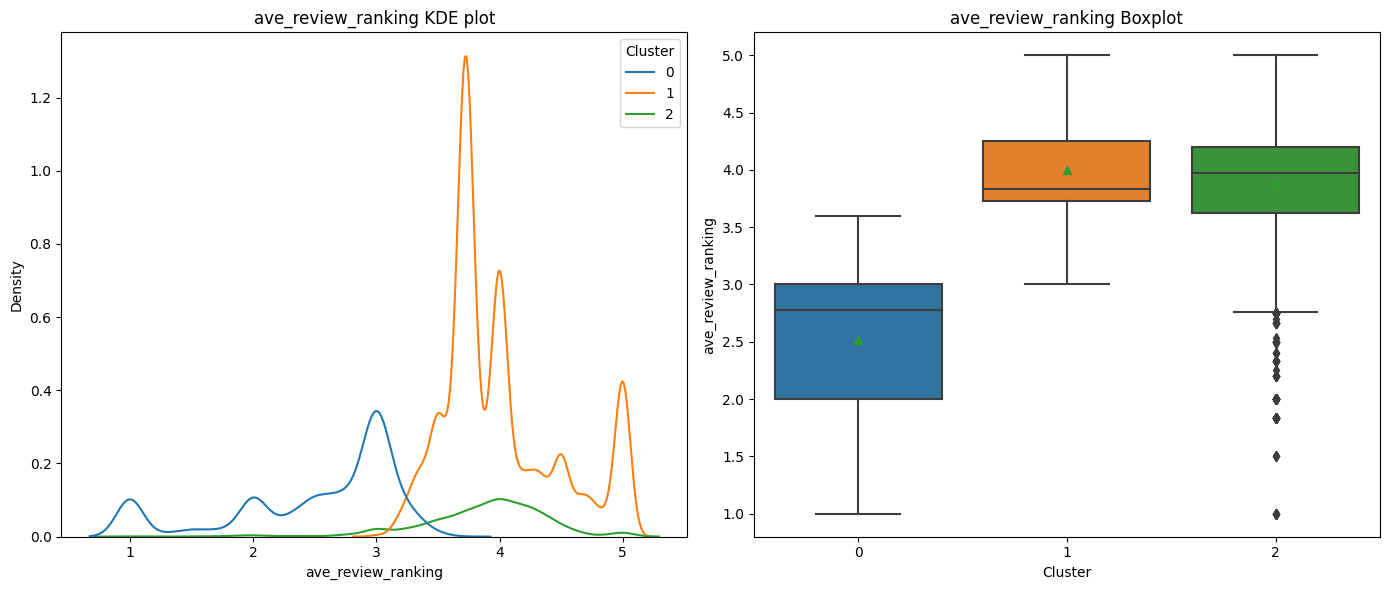

votes :

           count   mean     std  min    25%    50%     75%      max
Cluster                                                            
0       10213.00  91.01  153.40 0.00  10.00  36.00  108.00  1986.00
1       25823.00 162.77  472.25 0.00   0.00  23.00  121.00  8304.00
2        4094.00 958.47 1199.87 0.00 210.25 560.00 1281.00 12121.00




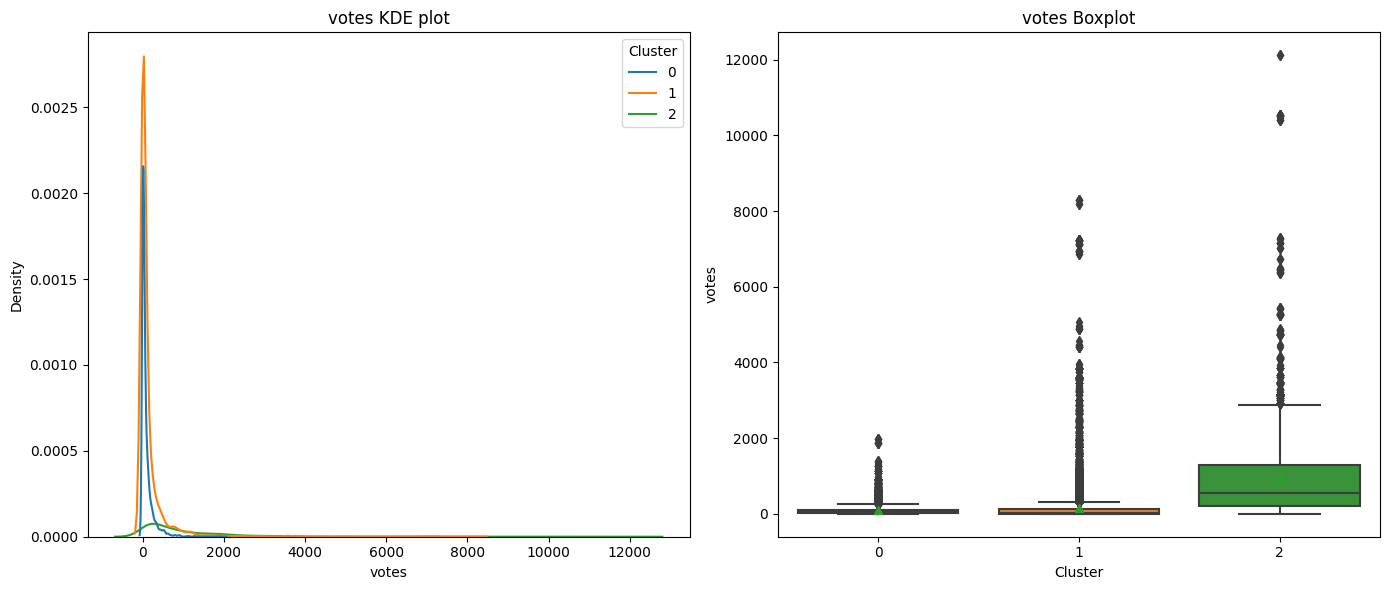

rate :

           count  mean  std  min  25%  50%  75%  max
Cluster                                             
0       10213.00  3.33 0.38 1.80 3.10 3.30 3.66 4.20
1       25823.00  3.72 0.28 2.30 3.60 3.66 3.90 4.90
2        4094.00  4.10 0.33 2.20 3.90 4.10 4.30 4.90




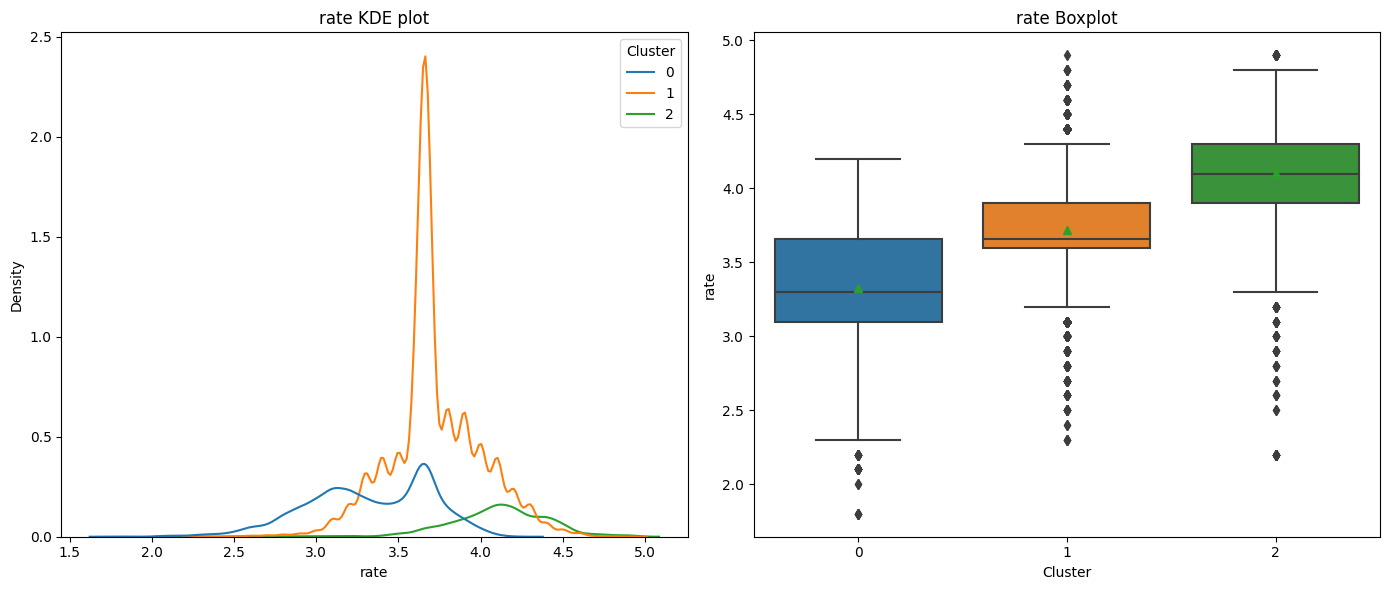

In [180]:
#Plotting Kernel Density Estimates and Boxplots for the below variables
nums=['ave_cost_for_two','ave_review_ranking', 'votes', 'rate']
for i in nums:
  print(i, ':\n')
  print(var.groupby('Cluster')[i].describe())
  print('\n')

  # Create subplots
  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  # Plot KDE on the first subplot
  sns.kdeplot(data=var, x=i, hue='Cluster', ax=axes[0], palette='tab10')
  axes[0].set_title(f'{i} KDE plot')

  # Plot Boxplot on the second subplot
  sns.boxplot(x='Cluster', y=i, data=var, showmeans=True, ax=axes[1], palette='tab10')
  axes[1].set_title(f'{i} Boxplot')

  plt.tight_layout()  # Adjust layout so plots do not overlap
  plt.show()

<Axes: xlabel='Cluster', ylabel='rate'>

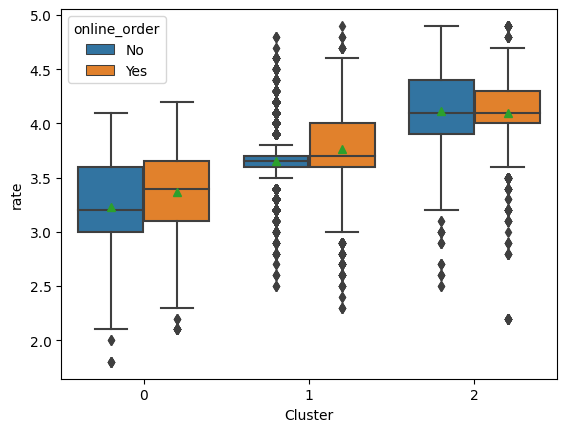

In [181]:
#Plotting Boxplot between Clusters and Rate with Hue as Online Order
sns.boxplot(x='Cluster', y='rate', data=var, showmeans=True,  hue='online_order', palette='tab10')

<Axes: xlabel='Cluster', ylabel='rate'>

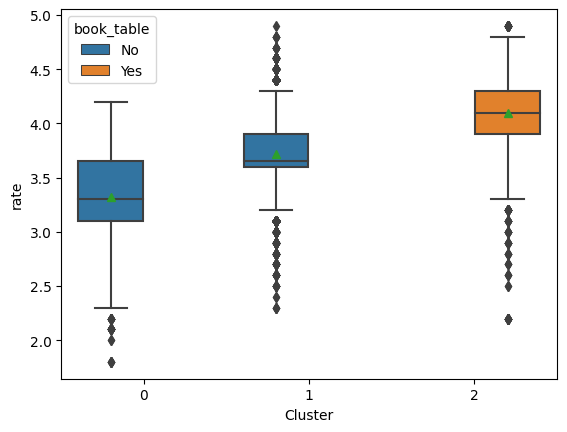

In [182]:
#Plotting Boxplot between Clusters and Rate with Hue as Book Table
sns.boxplot(x='Cluster', y='rate', data=var, showmeans=True,  hue='book_table')

In [183]:
#Printing X-Scaled Variable
X_scaled

,ave_cost_for_two,ave_review_ranking,votes,rate,book_table_N
0,0.27,0.00,0.94,0.00,0.58
1,0.15,0.00,0.88,0.00,0.65
2,0.07,0.00,0.75,0.00,0.68
3,0.47,0.05,0.95,1.00,0.81
4,0.09,0.01,0.50,0.00,0.61
...,...,...,...,...,...
40125,0.15,0.00,0.25,0.00,0.35
40126,0.19,0.00,0.61,0.00,0.58
40127,0.11,0.00,0.61,0.00,0.42
40128,0.19,0.01,0.62,0.00,0.71


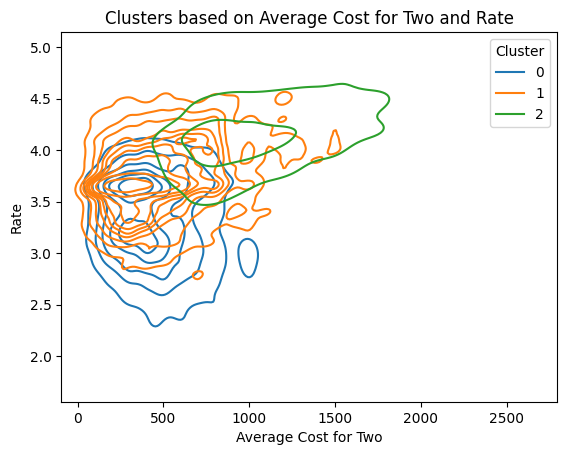

In [184]:
#Create the KDE plot for the Dataset
sns.kdeplot(data=var, x='ave_cost_for_two', y='rate', hue='Cluster', palette='tab10', legend='full')

# Setting the title and labels
plt.title('Clusters based on Average Cost for Two and Rate')
plt.xlabel('Average Cost for Two')
plt.ylabel('Rate')

plt.show()

###**7.1.5 Labelling clusters**

In [185]:
#Descriptive Measures of each Cluster
var.groupby('Cluster').rate.describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,10213.00,3.33,0.38,1.80,3.10,3.30,3.66,4.20
1,25823.00,3.72,0.28,2.30,3.60,3.66,3.90,4.90
2,4094.00,4.10,0.33,2.20,3.90,4.10,4.30,4.90


In [186]:
#Calculating mean for each cluster
cluster_summary = var.groupby('Cluster').mean()

#Printing out the summary statistics
print(cluster_summary)

#Manually assigning labels based on inspection
cluster_labels = {
    0: "No Table Booking, Low Average Review Ranking, Reasonable average cost for two, Moderately Popular",
    1: "No Table Booking, High Average Review Ranking, Reasonable average cost for two, Moderately popular",
    2: "Table booking Present, High Average Review Ranking, Expensive average cost for two, Highly popular",
}

# Adding a new column to the DataFrame with label names
var['Cluster_Label'] = var['Cluster'].map(cluster_labels)

         ave_cost_for_two  votes  ave_review_ranking  rate  online_order_N  \
Cluster                                                                      
0                  440.98  91.01                2.51  3.33            0.70   
1                  439.52 162.77                4.00  3.72            0.56   
2                 1088.12 958.47                3.88  4.10            0.71   

         book_table_N  rest_type_N  
Cluster                             
0                0.00         2.00  
1                0.00         2.10  
2                1.00         2.91  


<ipython-input-186-2acc5bfaa20e>:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  cluster_summary = var.groupby('Cluster').mean()


In [187]:
#Printing random sample of 20
var.sample(20)

,rest_type,listed_in_type,online_order,book_table,ave_cost_for_two,votes,ave_review_ranking,rate,online_order_N,book_table_N,rest_type_N,Cluster,Cluster_Label
3249,Quick Bites,Delivery,Yes,No,400.00,52,5.00,3.00,1,0,1,1,"No Table Booking, High Average Review Ranking,..."
37319,Casual Dining,Dine-out,Yes,No,1000.00,772,4.15,3.90,1,0,2,1,"No Table Booking, High Average Review Ranking,..."
27251,Casual Dining,Delivery,Yes,No,450.00,18,2.00,3.10,1,0,2,0,"No Table Booking, Low Average Review Ranking, ..."
10307,"Casual Dining, Bar",Dine-out,No,No,1200.00,122,3.15,3.10,0,0,6,0,"No Table Booking, Low Average Review Ranking, ..."
23283,"Takeaway, Delivery",Delivery,Yes,No,200.00,0,1.67,3.66,1,0,5,0,"No Table Booking, Low Average Review Ranking, ..."
28923,"Takeaway, Delivery",Delivery,Yes,No,500.00,0,3.73,3.66,1,0,5,1,"No Table Booking, High Average Review Ranking,..."
19538,Quick Bites,Delivery,Yes,No,350.00,281,3.00,3.80,1,0,1,0,"No Table Booking, Low Average Review Ranking, ..."
4800,Delivery,Delivery,No,No,300.00,0,3.73,3.66,0,0,4,1,"No Table Booking, High Average Review Ranking,..."
25316,Casual Dining,Delivery,Yes,No,600.00,36,3.73,3.40,1,0,2,1,"No Table Booking, High Average Review Ranking,..."
10141,Quick Bites,Delivery,Yes,No,400.00,171,3.67,4.10,1,0,1,1,"No Table Booking, High Average Review Ranking,..."


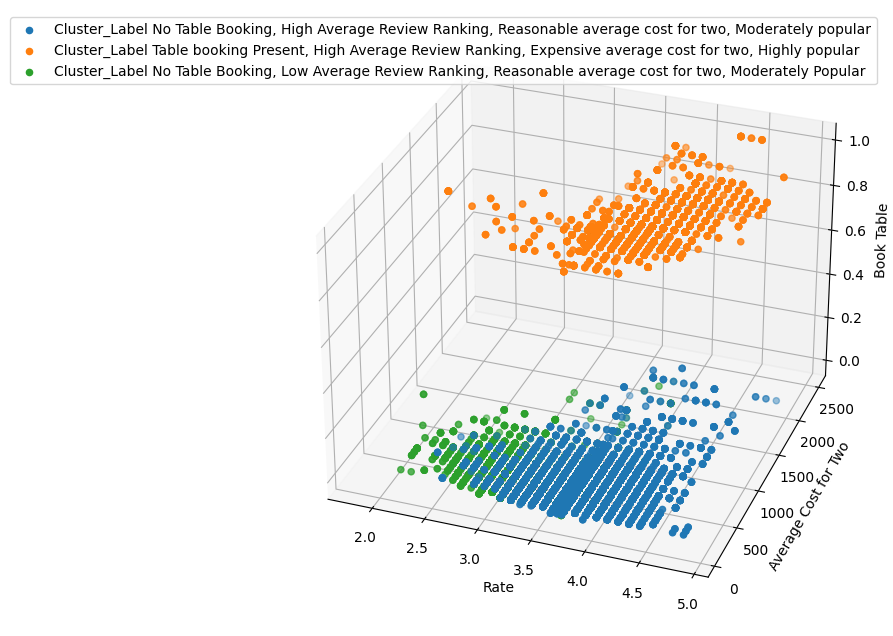

In [188]:
#Visualizing Clusters
from mpl_toolkits.mplot3d import Axes3D

# Create a new figure
fig = plt.figure(figsize=(12, 8))

# Add 3D subplot
# The '111' means 1x1 grid, first subplot, similar to MATLAB-style
ax = fig.add_subplot(111, projection='3d')

# Unique cluster labels
unique_clusters = var['Cluster_Label'].unique()

# Use Seaborn's tab10 palette
colors = sns.color_palette('tab10', len(unique_clusters))

# Adjusting the viewing angle for better visibility
ax.view_init(elev=30, azim=-70)  # Modify these values as needed

# Scatter plot for each cluster
for i, cluster in enumerate(unique_clusters):
    cluster_data = var[var['Cluster_Label'] == cluster]
    ax.scatter(cluster_data['rate'], cluster_data['ave_cost_for_two'], cluster_data['book_table_N'],
               label=f'Cluster_Label {cluster}', c=[colors[i]])

# Legend and labels
ax.set_xlabel('Rate')
ax.set_ylabel('Average Cost for Two')
ax.set_zlabel('Book Table')
ax.legend()

# Show the plot
plt.show()

In [189]:
#You can get each cluster out and examine them separately
cluster_0 = var[var['Cluster'] == 0]
cluster_1 = var[var['Cluster'] == 1]
cluster_2 = var[var['Cluster'] == 2]


In [190]:
#Describing Cluster 1
cluster_0.describe()

,ave_cost_for_two,votes,ave_review_ranking,rate,online_order_N,book_table_N,rest_type_N,Cluster
count,10213.00,10213.00,10213.00,10213.00,10213.00,10213.00,10213.00,10213.00
mean,440.98,91.01,2.51,3.33,0.70,0.00,2.00,0.00
std,210.32,153.40,0.69,0.38,0.46,0.00,1.45,0.00
min,40.00,0.00,1.00,1.80,0.00,0.00,1.00,0.00
25%,300.00,10.00,2.00,3.10,0.00,0.00,1.00,0.00
50%,400.00,36.00,2.78,3.30,1.00,0.00,1.00,0.00
75%,550.00,108.00,3.00,3.66,1.00,0.00,2.00,0.00
max,2000.00,1986.00,3.60,4.20,1.00,0.00,7.00,0.00


In [191]:
#Describing Cluster 2
cluster_1.describe()

,ave_cost_for_two,votes,ave_review_ranking,rate,online_order_N,book_table_N,rest_type_N,Cluster
count,25823.00,25823.00,25823.00,25823.00,25823.00,25823.00,25823.00,25823.00
mean,439.52,162.77,4.00,3.72,0.56,0.00,2.10,1.00
std,246.18,472.25,0.48,0.28,0.50,0.00,1.56,0.00
min,40.00,0.00,3.00,2.30,0.00,0.00,1.00,1.00
25%,300.00,0.00,3.73,3.60,0.00,0.00,1.00,1.00
50%,400.00,23.00,3.83,3.66,1.00,0.00,1.00,1.00
75%,550.00,121.00,4.25,3.90,1.00,0.00,3.00,1.00
max,2200.00,8304.00,5.00,4.90,1.00,0.00,7.00,1.00


In [192]:
#Describing Cluster 3
cluster_2.describe()

,ave_cost_for_two,votes,ave_review_ranking,rate,online_order_N,book_table_N,rest_type_N,Cluster
count,4094.00,4094.00,4094.00,4094.00,4094.00,4094.00,4094.00,4094.00
mean,1088.12,958.47,3.88,4.10,0.71,1.00,2.91,2.00
std,393.28,1199.87,0.52,0.33,0.45,0.00,1.59,0.00
min,200.00,0.00,1.00,2.20,0.00,1.00,1.00,2.00
25%,800.00,210.25,3.62,3.90,0.00,1.00,2.00,2.00
50%,1000.00,560.00,3.97,4.10,1.00,1.00,2.00,2.00
75%,1400.00,1281.00,4.20,4.30,1.00,1.00,3.00,2.00
max,2500.00,12121.00,5.00,4.90,1.00,1.00,6.00,2.00
